In [25]:
import pandas as pd
import numpy as np
import sys
import os
import re
import json
import glob
import time
from tqdm import tqdm
from typing import List, Dict, Optional
from dataclasses import dataclass, field
from dotenv import load_dotenv
from pathlib import Path
# Корень проекта Executive_Exocortex
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv()

from pydantic import BaseModel, Field, field_validator

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from langchain_openai import ChatOpenAI
from openai import OpenAI
from langfuse import Langfuse

# atomizer, linker, GraphRAG
from config.settings import settings
from zettelkasten.atomizer import NoteAtomizer
from zettelkasten.linker import (
    GraphLinker,
    LocalEmbeddingModel,
    LinkAction,
)

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Atomizer

## analyze and visualize atomizer results

In [9]:
# стоимость моделей
df_costs = pd.read_excel('price_data/llm_prices.xlsx')

df_costs['Цена вход'] = df_costs['ЦЕНА'].str.extract(r'Вход:\s*([\d.]+)').astype(float)
df_costs['Цена выход'] = df_costs['ЦЕНА'].str.extract(r'Выход:\s*([\d.]+)').astype(float)
choose_models  = [
    'gpt-4o-mini\nopenai/gpt-4o-mini',
    'gemini-2.5-flash\ngoogle/gemini-2.5-flash',
    'claude-haiku-4.5\nanthropic/claude-haiku-4.5',
]
df_costs[df_costs['МОДЕЛЬ'].isin(choose_models)].sort_values(by=['Цена вход', 'Цена выход'], ascending=False)

,МОДЕЛЬ,ВЕНДОР,КАТЕГОРИЯ,ЦЕНА,Цена вход,Цена выход
71,claude-haiku-4.5\nanthropic/claude-haiku-4.5,Anthropic,Общего назначения,Вход: 108 ₽/М\nВыход: 540 ₽/М,108.0,540.0
83,gemini-2.5-flash\ngoogle/gemini-2.5-flash,Google,Общего назначения,Вход: 32.40 ₽/М\nВыход: 270 ₽/М,32.4,270.0
11,gpt-4o-mini\nopenai/gpt-4o-mini,OpenAI,Общего назначения,Вход: 16.20 ₽/М\nВыход: 64.80 ₽/М,16.2,64.8


In [10]:
def load_all_metrics():
    """Загружает все метрики из Excel файлов"""
    
    # Summary (итоговая таблица)
    df_summary = pd.read_excel("metric_results/atomizer/summary_comparison.xlsx", index_col=0)
    
    # Все метрики по заметкам
    df_all = pd.read_excel("metric_results/atomizer/all_models_atomizer_metrics.xlsx")
    
    # Отдельные метрики по моделям
    metrics_files = list(Path("metric_results/atomizer").glob("atomizer_metrics_*.xlsx"))
    df_by_model = {}
    for f in metrics_files:
        model_name = f.stem.replace("atomizer_metrics_", "")
        df_by_model[model_name] = pd.read_excel(f)
    
    return df_summary, df_all, df_by_model


df_summary, df_all, df_by_model = load_all_metrics()

In [11]:
def normalize_metric_correct(values, metric_name):
    """
    Нормализует метрику относительно её теоретических границ.
    """
    
    # Определяем теоретические границы для каждой метрики
    bounds = {
        'tag_f1': (0.0, 1.0),
        'tag_precision': (0.0, 1.0),
        'tag_recall': (0.0, 1.0),
        'semantic_similarity_mean': (0.0, 1.0),
        'faithfulness_score': (0.0, 1.0),
        'hallucination_score': (0.0, 1.0),
        'semantic_coverage_ratio': (0.0, 1.0),
        'hallucination_ratio': (0.0, 1.0),
        'pred_hierarchy_valid_ratio': (0.0, 1.0),
        'thought_type_distribution_overlap': (0.0, 1.0),
        
        # Для метрик без естественных границ используем разумные пределы
        'latency_ms_total': (0, 30000),  # 0-30 секунд
        'count_ratio': (0.5, 1.5),       # ±50% от идеального
        'count_mae': (0, 10),             # до 10 мыслей разницы
        'root_count_delta': (0, 10),
        'depth_mae': (0, 5),
    }
    
    min_bound, max_bound = bounds.get(metric_name, (values.min(), values.max()))
    
    # Clip значения в границы (на случай выбросов)
    values_clipped = np.clip(values, min_bound, max_bound)
    
    # Нормализуем
    if max_bound == min_bound:
        return pd.Series([1.0] * len(values), index=values.index)
    
    return (values_clipped - min_bound) / (max_bound - min_bound)

In [12]:
def normalize_percentile(values, lower_percentile=5, upper_percentile=95):
    """
    Нормализует по перцентилям (устойчиво к выбросам).
    Но при 3 моделях это не поможет.
    """
    p_low = np.percentile(values, lower_percentile)
    p_high = np.percentile(values, upper_percentile)
    
    return np.clip((values - p_low) / (p_high - p_low), 0, 1)

In [13]:
def normalize_sigmoid(values, target=None, scale=1.0):
    """
    Сигмоидная нормализация — плавный переход.
    Хорошо работает для метрик с целевым значением.
    """
    if target is not None:
        # Для count_ratio (target = 1.0)
        deviation = np.abs(values - target)
        return 1 / (1 + np.exp(deviation / scale))
    else:
        # Стандартная сигмоида
        return 1 / (1 + np.exp(-values))

✅ Данные загружены
   Количество заметок: 200
   Количество моделей: 3
   Модели: ['anthropic/claude-haiku-4.5', 'openai/gpt-4o-mini', 'google/gemini-2.5-flash']

💰 Стоимость моделей (цена входа, ₽/М токенов):
   • openai/gpt-4o-mini                      : 16.20 ₽
   • google/gemini-2.5-flash                 : 32.40 ₽
   • anthropic/claude-haiku-4.5              : 108.00 ₽

📊 СЫРЫЕ ЗНАЧЕНИЯ МЕТРИК
                            latency_ms_total  count_ratio  count_mae  pred_hierarchy_valid_ratio  root_count_delta  depth_mae  tag_f1  tag_precision  tag_recall  semantic_similarity_mean  semantic_coverage_ratio  hallucination_ratio  faithfulness_score  hallucination_score  thought_type_distribution_overlap
model_name                                                                                                                                                                                                                                                                                        

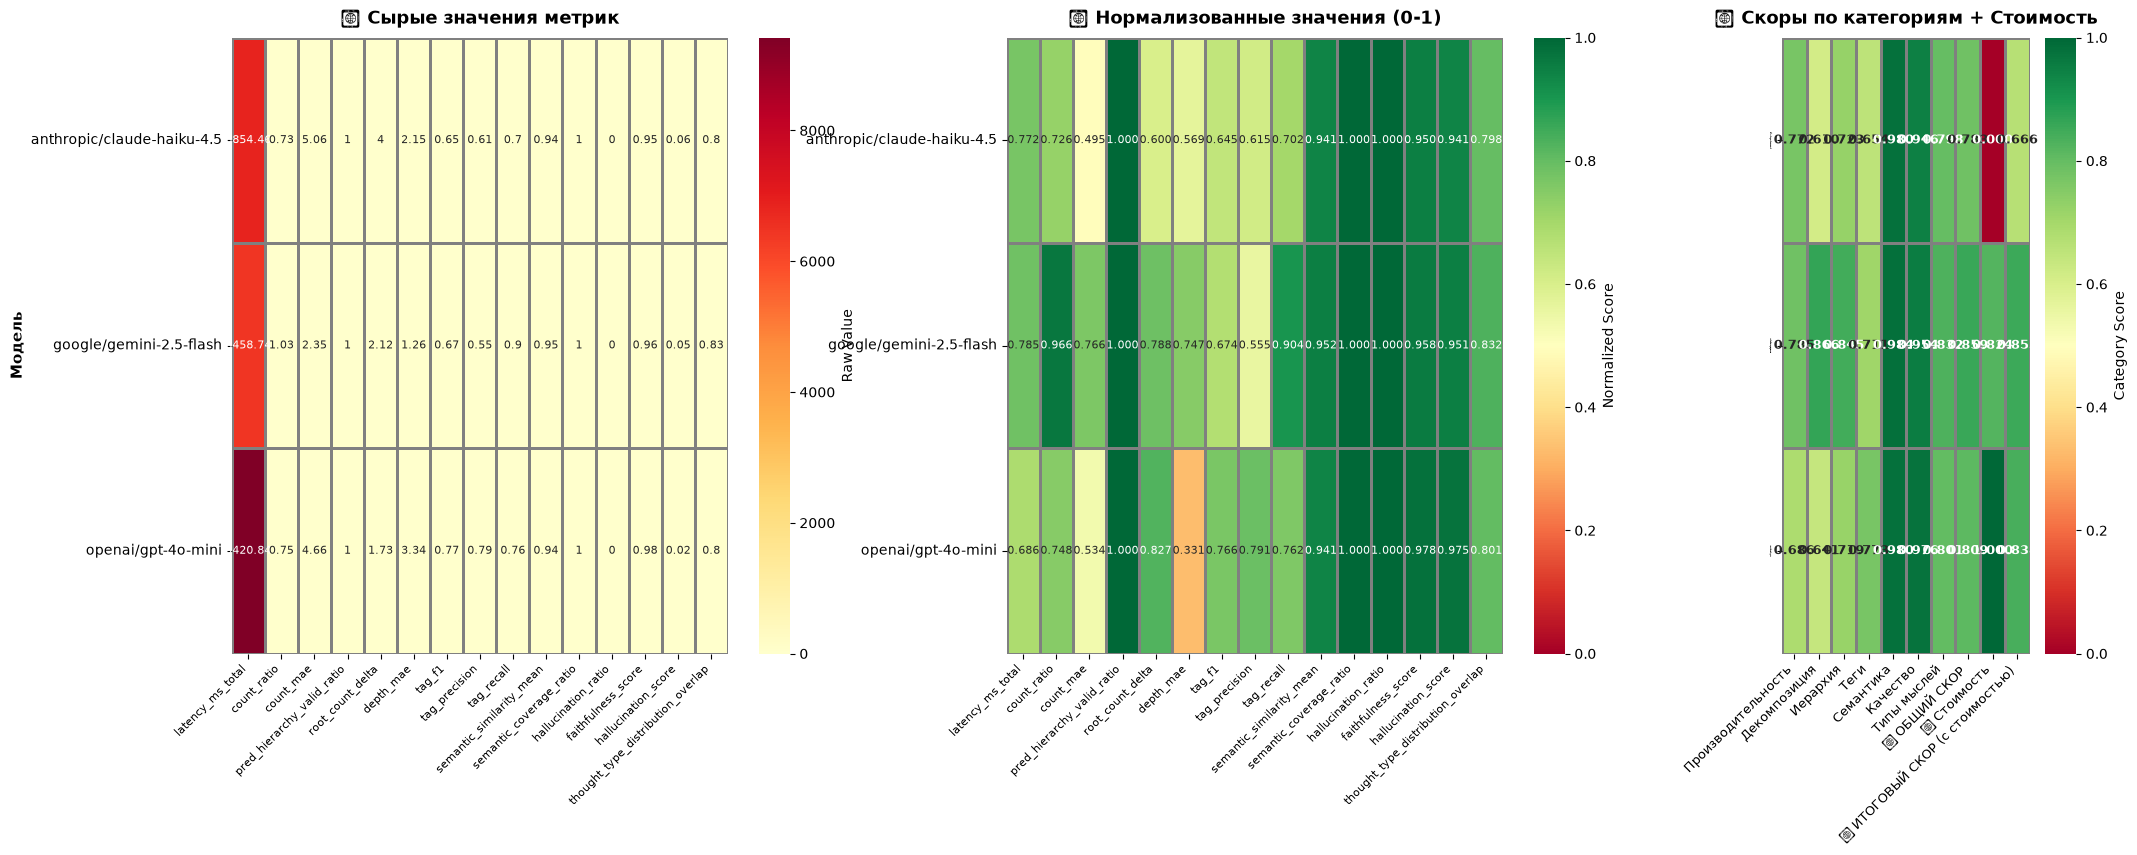

✅ Heatmap 'Производительность' сохранена


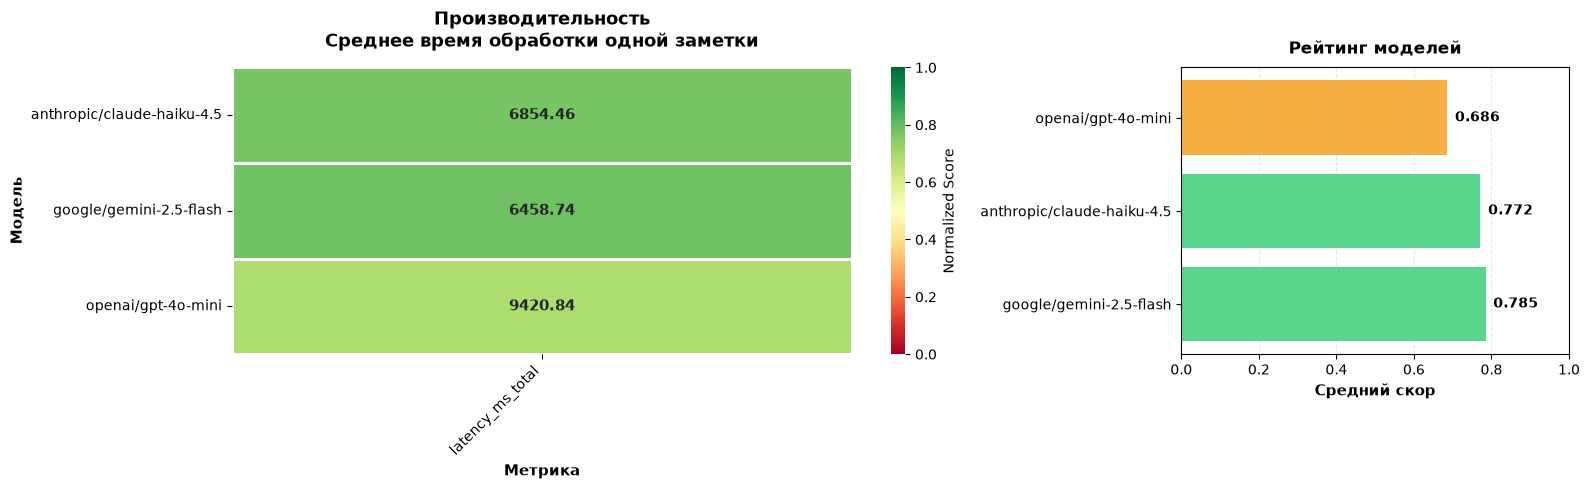

✅ Heatmap 'Декомпозиция' сохранена


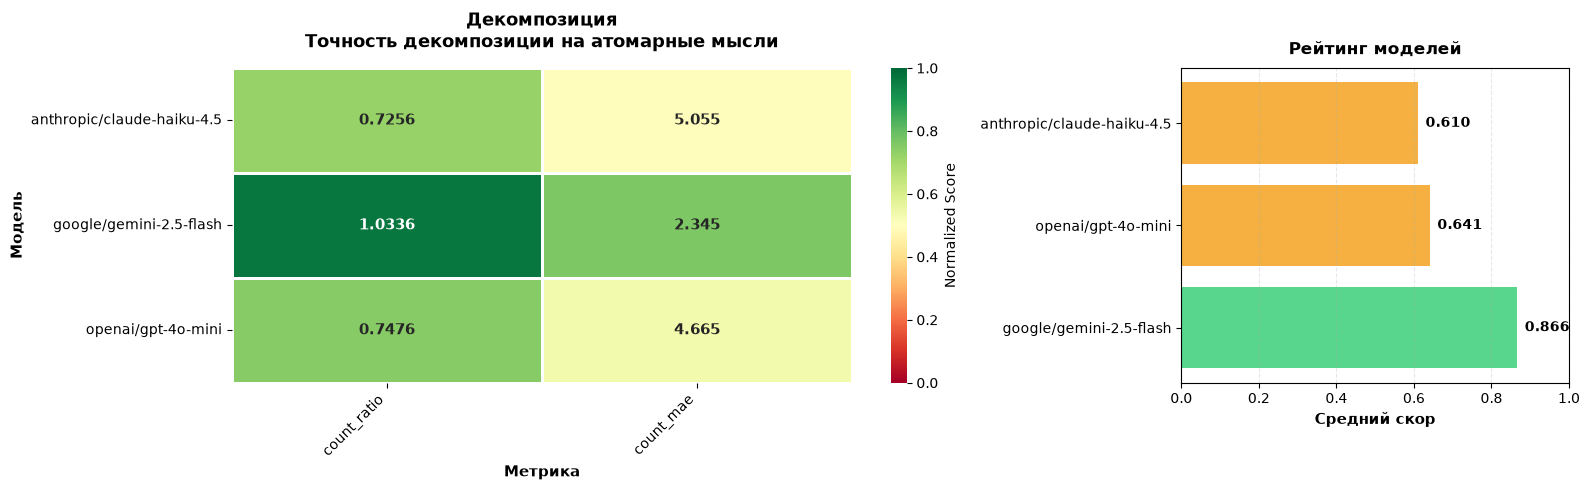

✅ Heatmap 'Иерархия' сохранена


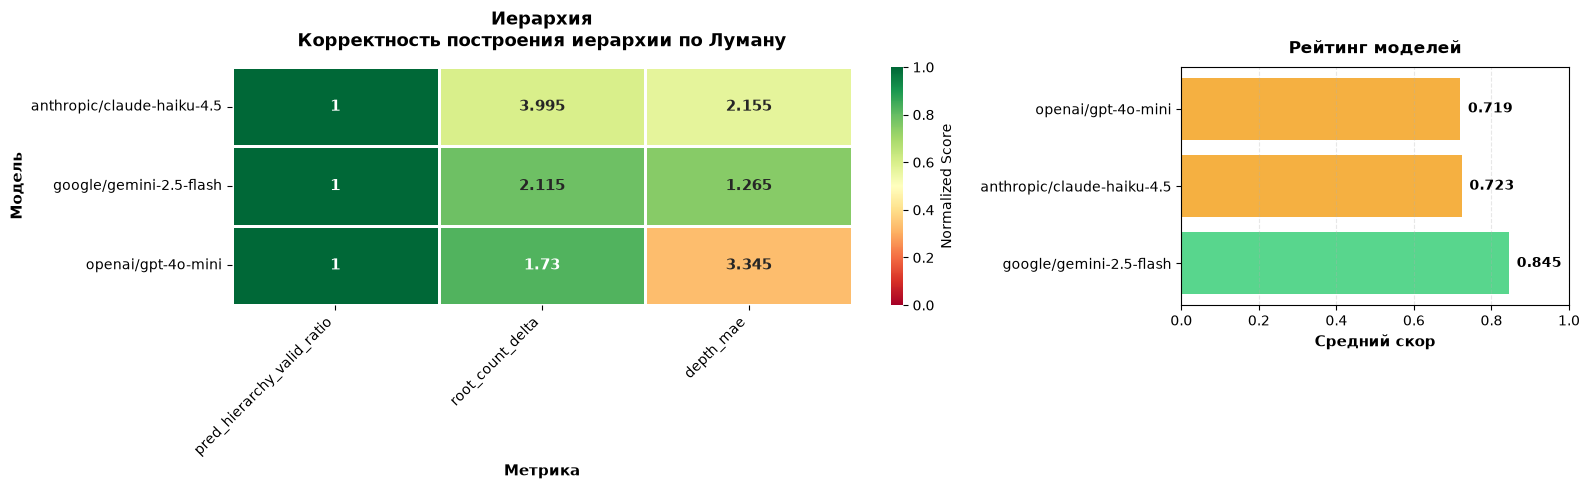

✅ Heatmap 'Теги' сохранена


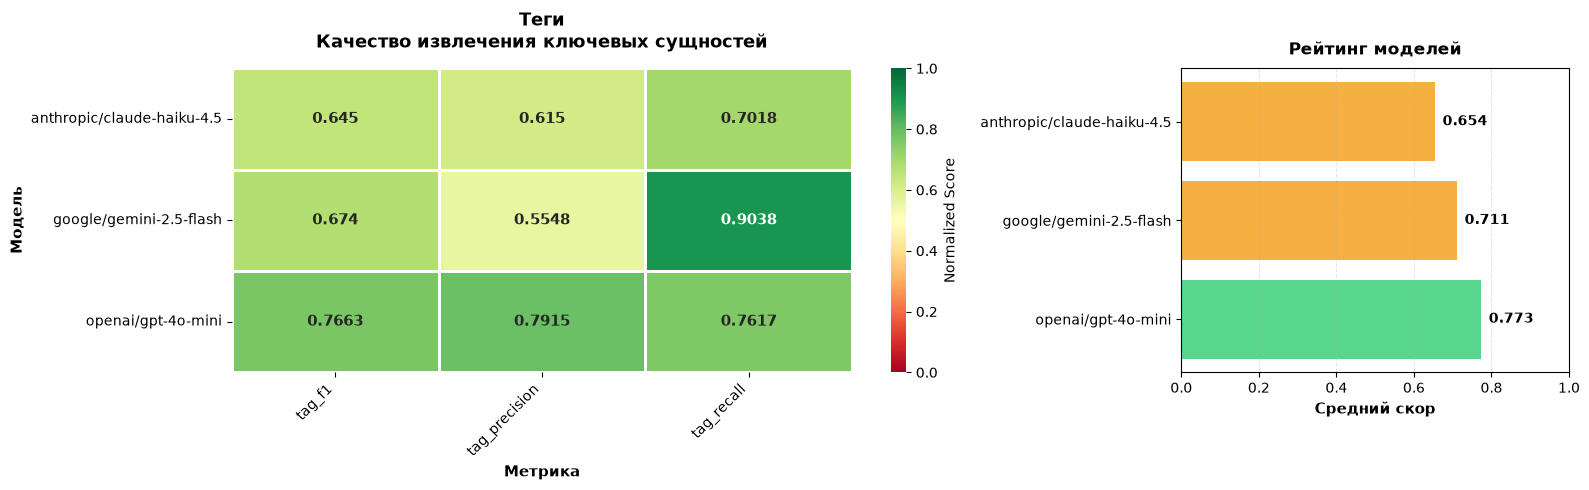

✅ Heatmap 'Семантика' сохранена


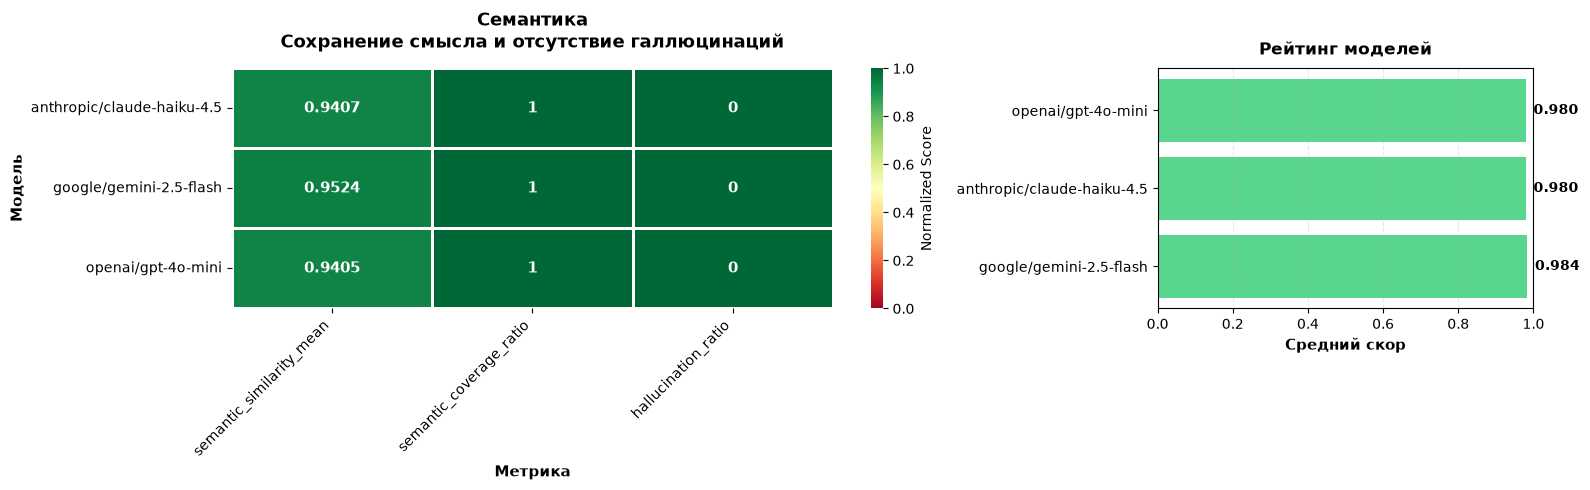

✅ Heatmap 'Качество' сохранена


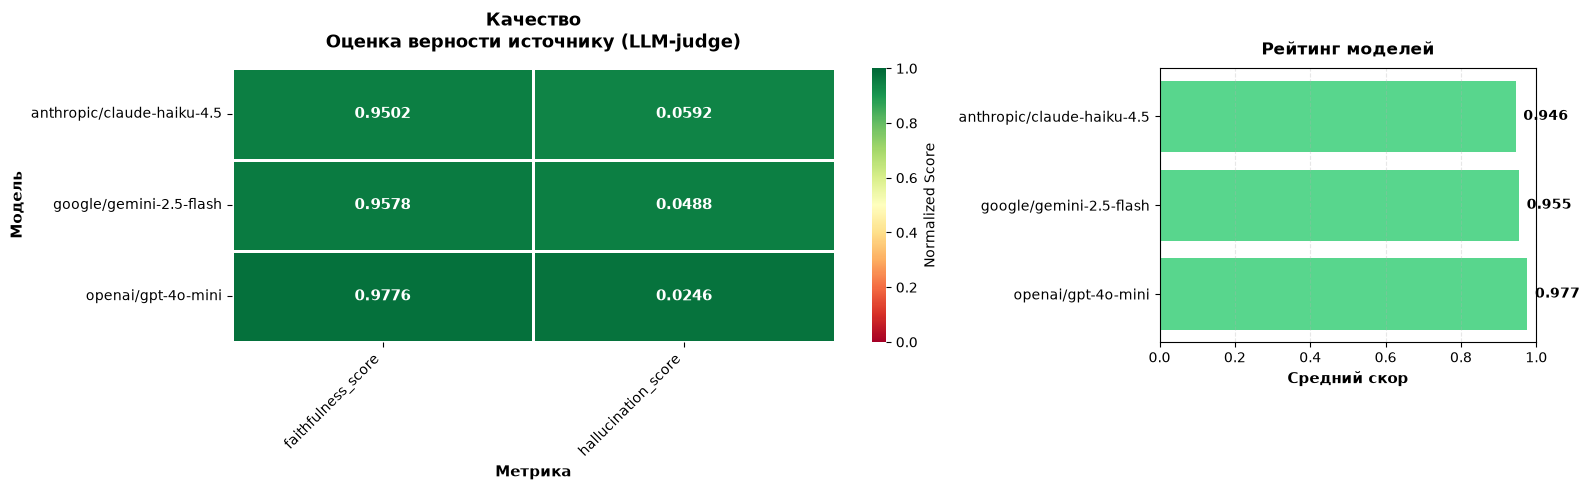

✅ Radar chart сохранён: radar_chart.png


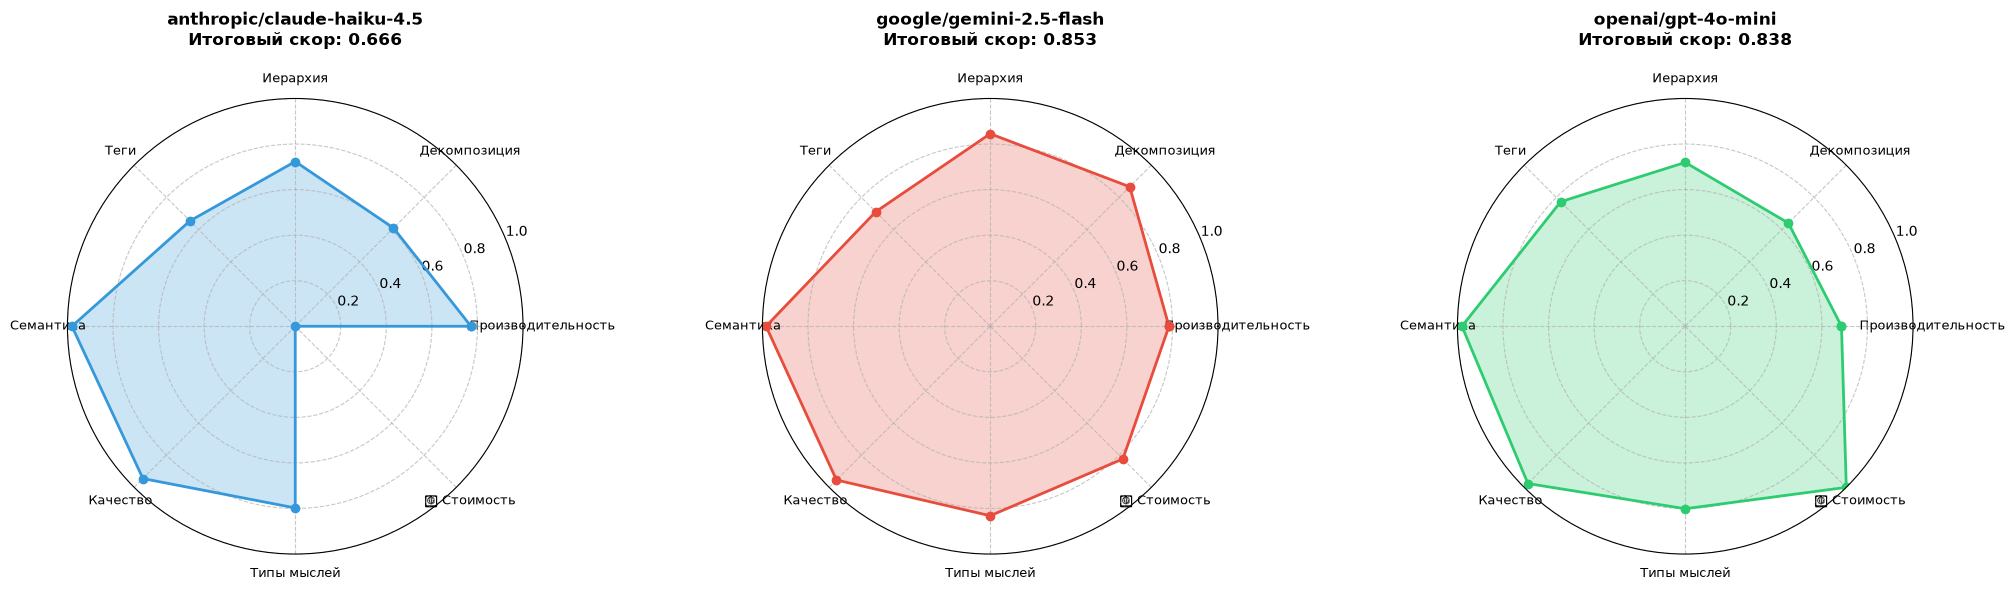

✅ Summary bar chart сохранён: summary_barchart.png


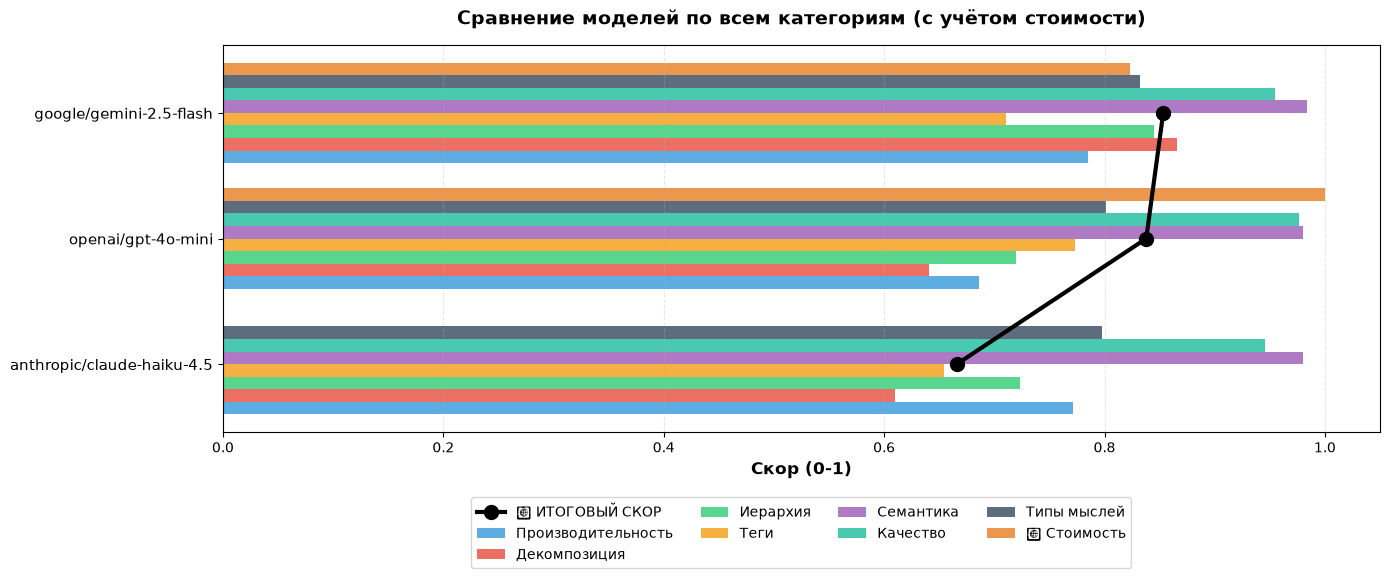

✅ Итоговый отчёт сохранён: FINAL_REPORT.txt

Созданные файлы:
  📊 heatmap_main.png - главная heatmap со всеми метриками
  📊 heatmap_*.png - детальные heatmaps по категориям (6 шт)
  🕸️  radar_chart.png - паутинка для сравнения
  📊 summary_barchart.png - сводный bar chart со всеми блоками и черной линией
  📋 scoreboard_with_cost.xlsx - таблица скоров со стоимостью
  📋 final_summary_with_cost.xlsx - итоговая таблица сравнения со стоимостью
  📝 FINAL_REPORT.txt - текстовый итоговый отчёт


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ────────────────────────────────────────────────────────────
# 1. ЗАГРУЗКА ДАННЫХ
# ────────────────────────────────────────────────────────────

def load_all_metrics():
    """Загружает все метрики из Excel файлов"""
    df_all = pd.read_excel("metric_results/atomizer/all_models_atomizer_metrics.xlsx")
    return df_all


def load_model_costs():
    """Загружает стоимость моделей из файла цен"""
    df_costs = pd.read_excel('price_data/llm_prices.xlsx')
    
    # Парсим цены из строки
    df_costs['Цена вход'] = df_costs['ЦЕНА'].str.extract(r'Вход:\s*([\d.]+)').astype(float)
    df_costs['Цена выход'] = df_costs['ЦЕНА'].str.extract(r'Выход:\s*([\d.]+)').astype(float)
    
    # Вычисляем среднюю цену (примерно 1 токен вход = 1 токен выход)
    df_costs['Средняя цена'] = (df_costs['Цена вход'] + df_costs['Цена выход']) / 2
    
    # Нормализуем названия моделей для маппинга
    model_mapping = {
        'anthropic/claude-haiku-4.5': 108.0,    # берём цену входа как главную метрику
        'google/gemini-2.5-flash': 32.4,
        'openai/gpt-4o-mini': 16.2,
    }
    
    return model_mapping


df_all = load_all_metrics()
model_costs = load_model_costs()

print("✅ Данные загружены")
print(f"   Количество заметок: {df_all['note_id'].nunique()}")
print(f"   Количество моделей: {df_all['model_name'].nunique()}")
print(f"   Модели: {df_all['model_name'].unique().tolist()}\n")

print("💰 Стоимость моделей (цена входа, ₽/М токенов):")
for model, cost in sorted(model_costs.items(), key=lambda x: x[1]):
    print(f"   • {model:40s}: {cost:.2f} ₽")
print()


# ────────────────────────────────────────────────────────────
# 2. ПРАВИЛЬНАЯ НОРМАЛИЗАЦИЯ
# ────────────────────────────────────────────────────────────

def create_normalized_scorecard_correct(df_all: pd.DataFrame) -> tuple:
    """
    Создаёт ПРАВИЛЬНУЮ нормализованную таблицу.
    Использует теоретические границы метрик, а не min/max выборки.
    """
    
    metrics_config = {
        'latency_ms_total': {
            'higher_is_better': False,
            'bounds': (0, 30000),
        },
        'count_ratio': {
            'higher_is_better': None,
            'target': 1.0,
            'bounds': (0.0, 2.0),
        },
        'count_mae': {
            'higher_is_better': False,
            'bounds': (0, 10),
        },
        'pred_hierarchy_valid_ratio': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'root_count_delta': {
            'higher_is_better': False,
            'bounds': (0, 10),
        },
        'depth_mae': {
            'higher_is_better': False,
            'bounds': (0, 5),
        },
        'tag_f1': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'tag_precision': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'tag_recall': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'semantic_similarity_mean': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'semantic_coverage_ratio': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'hallucination_ratio': {
            'higher_is_better': False,
            'bounds': (0.0, 1.0),
        },
        'faithfulness_score': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
        'hallucination_score': {
            'higher_is_better': False,
            'bounds': (0.0, 1.0),
        },
        'thought_type_distribution_overlap': {
            'higher_is_better': True,
            'bounds': (0.0, 1.0),
        },
    }
    
    available_metrics = [m for m in metrics_config.keys() if m in df_all.columns]
    df_raw = df_all.groupby('model_name')[available_metrics].mean()
    df_norm = df_raw.copy()
    
    for metric, config in metrics_config.items():
        if metric not in df_raw.columns:
            continue
        
        values = df_raw[metric]
        min_bound, max_bound = config['bounds']
        higher_is_better = config.get('higher_is_better')
        target = config.get('target')
        
        values_clipped = np.clip(values, min_bound, max_bound)
        
        if target is not None:
            max_deviation = max(abs(min_bound - target), abs(max_bound - target))
            deviation = np.abs(values_clipped - target)
            df_norm[metric] = 1 - (deviation / max_deviation)
            
        elif higher_is_better is True:
            if max_bound == min_bound:
                df_norm[metric] = 1.0
            else:
                df_norm[metric] = (values_clipped - min_bound) / (max_bound - min_bound)
        
        elif higher_is_better is False:
            if max_bound == min_bound:
                df_norm[metric] = 1.0
            else:
                df_norm[metric] = 1 - (values_clipped - min_bound) / (max_bound - min_bound)
    
    return df_raw, df_norm, metrics_config


df_raw, df_norm, metrics_config = create_normalized_scorecard_correct(df_all)

print("="*100)
print("📊 СЫРЫЕ ЗНАЧЕНИЯ МЕТРИК")
print("="*100)
print(df_raw.round(4).to_string())

print("\n" + "="*100)
print("📈 НОРМАЛИЗОВАННЫЕ ЗНАЧЕНИЯ (0-1, где 1 = лучше)")
print("="*100)
print(df_norm.round(4).to_string())


# ────────────────────────────────────────────────────────────
# 3. СКОР ПО КАТЕГОРИЯМ + ОБЩИЙ СКОР (БЕЗ СТОИМОСТИ)
# ────────────────────────────────────────────────────────────

def compute_scores_by_category(df_norm: pd.DataFrame) -> pd.DataFrame:
    """Считает скоры по категориям и общий скор"""
    
    categories = {
        'Производительность': ['latency_ms_total'],
        'Декомпозиция': ['count_ratio', 'count_mae'],
        'Иерархия': ['pred_hierarchy_valid_ratio', 'root_count_delta', 'depth_mae'],
        'Теги': ['tag_f1', 'tag_precision', 'tag_recall'],
        'Семантика': ['semantic_similarity_mean', 'semantic_coverage_ratio', 'hallucination_ratio'],
        'Качество': ['faithfulness_score', 'hallucination_score'],
        'Типы мыслей': ['thought_type_distribution_overlap'],
    }
    
    scores = {}
    
    for category, cols in categories.items():
        existing_cols = [c for c in cols if c in df_norm.columns]
        if existing_cols:
            scores[category] = df_norm[existing_cols].mean(axis=1)
    
    df_scores = pd.DataFrame(scores)
    df_scores['🏆 ОБЩИЙ СКОР'] = df_norm.mean(axis=1)
    
    return df_scores


df_scores = compute_scores_by_category(df_norm)


# ────────────────────────────────────────────────────────────
# 🆕 ДОБАВЛЕНИЕ СТОИМОСТИ В ОБЩИЙ СКОР
# ────────────────────────────────────────────────────────────

def compute_scores_with_cost(df_scores: pd.DataFrame, model_costs: dict, cost_weight: float = 0.15) -> pd.DataFrame:
    """
    Вычисляет ОБЩИЙ СКОР с учётом стоимости модели.
    """
    
    df_scores_with_cost = df_scores.copy()
    
    costs = []
    cost_norms = []
    
    for model in df_scores.index:
        cost = model_costs.get(model, None)
        if cost is not None:
            costs.append(cost)
    
    if costs:
        min_cost = min(costs)
        max_cost = max(costs)
        
        for model in df_scores.index:
            cost = model_costs.get(model, None)
            if cost is not None:
                if max_cost == min_cost:
                    cost_norm = 1.0
                else:
                    cost_norm = 1 - (cost - min_cost) / (max_cost - min_cost)
                cost_norms.append(cost_norm)
            else:
                cost_norms.append(0.5)
    
    df_scores_with_cost['💰 Стоимость'] = pd.Series(cost_norms, index=df_scores.index)
    
    quality_score = df_scores_with_cost['🏆 ОБЩИЙ СКОР']
    cost_score = df_scores_with_cost['💰 Стоимость']
    
    df_scores_with_cost['🏅 ИТОГОВЫЙ СКОР (с стоимостью)'] = (
        quality_score * (1 - cost_weight) + cost_score * cost_weight
    )
    
    return df_scores_with_cost


df_scores_with_cost = compute_scores_with_cost(df_scores, model_costs, cost_weight=0.15)

print("\n" + "="*100)
print("💰 СКОРЫ СО СТОИМОСТЬЮ МОДЕЛЕЙ (вес стоимости = 15%)")
print("="*100)
print(df_scores_with_cost.round(4).to_string())

df_scores_with_cost.to_excel("metric_results/atomizer/scoreboard_with_cost.xlsx")


# ────────────────────────────────────────────────────────────
# 4. ВЫВОД ИТОГОВОЙ СВОДКИ (ГЛАВНАЯ ТАБЛИЦА)
# ────────────────────────────────────────────────────────────

def print_final_summary(df_raw: pd.DataFrame, df_norm: pd.DataFrame, df_scores: pd.DataFrame, 
                       df_scores_with_cost: pd.DataFrame, model_costs: dict):
    """Выводит финальную сводку с общими итогами и стоимостью"""
    
    print("\n\n" + "="*100)
    print("💰 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (СО СТОИМОСТЬЮ, вес = 15%)")
    print("="*100)
    
    final_scores_with_cost = df_scores_with_cost['🏅 ИТОГОВЫЙ СКОР (с стоимостью)'].sort_values(ascending=False)
    summary_data_cost = []
    
    for rank, (model, overall_score) in enumerate(final_scores_with_cost.items(), 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"#{rank}"
        cost = model_costs.get(model, 0)
        
        row = {
            'Ранг': medal,
            'Модель': model,
            'Цена (₽/М)': f"{cost:.2f}",
            'Стоимость (скор)': f"{df_scores_with_cost.loc[model, '💰 Стоимость']:.3f}",
            'Качество (скор)': f"{df_scores_with_cost.loc[model, '🏆 ОБЩИЙ СКОР']:.3f}",
            'ИТОГОВЫЙ СКОР': f"{overall_score:.4f}",
            'Процент': f"{int(overall_score * 100)}%",
        }
        summary_data_cost.append(row)
    
    df_summary_cost = pd.DataFrame(summary_data_cost)
    print("\n" + df_summary_cost.to_string(index=False))
    df_summary_cost.to_excel("metric_results/atomizer/final_summary_with_cost.xlsx", index=False)
    
    print("\n\n" + "="*100)
    print("🏅 ДЕТАЛЬНЫЙ РЕЙТИНГ МОДЕЛЕЙ (СО СТОИМОСТЬЮ)")
    print("="*100)
    
    for rank, (model, score) in enumerate(final_scores_with_cost.items(), 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"  {rank}."
        pct = int(score * 100)
        bar = "█" * (pct // 5) + "░" * ((100 - pct) // 5)
        cost = model_costs.get(model, 0)
        
        print(f"\n{medal} {model:40s}")
        print(f"   💰 Цена: {cost:.2f} ₽/М | 📊 Качество: {df_scores_with_cost.loc[model, '🏆 ОБЩИЙ СКОР']:.3f} | 💵 Стоимость: {df_scores_with_cost.loc[model, '💰 Стоимость']:.3f}")
        print(f"   🏅 Итоговый скор: {score:.4f} | {pct}% | [{bar}]")
    
    print("\n\n" + "="*100)
    print("🔍 ЛУЧШИЕ И ХУДШИЕ МОДЕЛИ ПО КАЖДОЙ МЕТРИКЕ")
    print("="*100)
    
    for col in df_raw.columns:
        if col not in df_norm.columns:
            continue
        
        best_model = df_raw[col].idxmax()
        best_value = df_raw[col].max()
        worst_model = df_raw[col].idxmin()
        worst_value = df_raw[col].min()
        
        if col in metrics_config:
            higher_is_better = metrics_config[col].get('higher_is_better')
            if higher_is_better is False or (higher_is_better is None and col == 'count_ratio'):
                best_model, worst_model = worst_model, best_model
                best_value, worst_value = worst_value, best_value
        
        print(f"\n{col:40s}")
        print(f"  🥇 Лучше:  {best_model:35s} → {best_value:.4f}")
        print(f"  ❌ Хуже:   {worst_model:35s} → {worst_value:.4f}")
    
    print("\n\n" + "="*100)
    print("📋 ИТОГОВЫЕ РЕКОМЕНДАЦИИ")
    print("="*100)
    
    best_model_overall = final_scores_with_cost.idxmax()
    best_score_overall = final_scores_with_cost.max()
    
    print(f"\n✅ ЛУЧШАЯ МОДЕЛЬ ПО КАЧЕСТВУ И СТОИМОСТИ: {best_model_overall}")
    print(f"   Итоговый скор: {best_score_overall:.4f} ({int(best_score_overall*100)}%)")
    print(f"   Цена: {model_costs.get(best_model_overall, 0):.2f} ₽/М")
    
    print(f"\n📊 Анализ {best_model_overall}:")
    best_categories = df_scores_with_cost.loc[best_model_overall].drop(['💰 Стоимость', '🏅 ИТОГОВЫЙ СКОР (с стоимостью)', '🏆 ОБЩИЙ СКОР']).sort_values(ascending=False)
    
    strong = best_categories[best_categories > 0.75]
    weak = best_categories[best_categories < 0.6]
    
    if len(strong) > 0:
        print(f"\n   💪 Сильные стороны (скор > 0.75):")
        for cat, score in strong.items():
            print(f"      • {cat}: {score:.3f}")
    
    if len(weak) > 0:
        print(f"\n   ⚠️  Слабые стороны (скор < 0.6):")
        for cat, score in weak.items():
            print(f"      • {cat}: {score:.3f}")
            print(f"        → Рекомендация: Улучшить {cat.lower()}")


print_final_summary(df_raw, df_norm, df_scores, df_scores_with_cost, model_costs)


# ────────────────────────────────────────────────────────────
# 5. ГЛАВНАЯ HEATMAP (С УЧЕТОМ СТОИМОСТИ)
# ────────────────────────────────────────────────────────────

def create_main_heatmap(df_raw: pd.DataFrame, df_norm: pd.DataFrame, df_scores_with_cost: pd.DataFrame):
    """Создаёт главную heatmap"""
    
    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[2, 2, 1], hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    
    # Левая: сырые значения
    sns.heatmap(
        df_raw,
        annot=df_raw.round(2),
        fmt='g',
        cmap='YlOrRd',
        cbar_kws={'label': 'Raw Value'},
        linewidths=1,
        linecolor='gray',
        ax=ax1,
        annot_kws={'size': 8},
    )
    ax1.set_title('📊 Сырые значения метрик', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylabel('Модель', fontsize=11, fontweight='bold')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=10)
    
    # Средняя: нормализованные значения
    sns.heatmap(
        df_norm,
        annot=df_norm.round(3),
        fmt='.3f',
        cmap='RdYlGn',
        cbar_kws={'label': 'Normalized Score'},
        linewidths=1,
        linecolor='gray',
        ax=ax2,
        vmin=0,
        vmax=1,
        annot_kws={'size': 8},
    )
    ax2.set_title('📈 Нормализованные значения (0-1)', fontsize=13, fontweight='bold', pad=10)
    ax2.set_ylabel('')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax2.get_yticklabels(), rotation=0, fontsize=10)
    
    # Правая: скоры по категориям + стоимость
    sns.heatmap(
        df_scores_with_cost,
        annot=df_scores_with_cost.round(3),
        fmt='.3f',
        cmap='RdYlGn',
        cbar_kws={'label': 'Category Score'},
        linewidths=1,
        linecolor='gray',
        ax=ax3,
        vmin=0,
        vmax=1,
        annot_kws={'size': 9, 'weight': 'bold'},
    )
    ax3.set_title('🎯 Скоры по категориям + Стоимость', fontsize=13, fontweight='bold', pad=10)
    ax3.set_ylabel('')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax3.get_yticklabels(), fontsize=0)
    
    plt.tight_layout()
    plt.savefig("metric_results/atomizer/heatmap_main.png", dpi=300, bbox_inches='tight')
    print("✅ Главная heatmap сохранена: heatmap_main.png")
    plt.show()
    plt.close()


create_main_heatmap(df_raw, df_norm, df_scores_with_cost)


# ────────────────────────────────────────────────────────────
# 6. ДЕТАЛЬНЫЕ HEATMAPS ПО КАТЕГОРИЯМ
# ────────────────────────────────────────────────────────────

def create_category_heatmaps_detailed(df_raw: pd.DataFrame, df_norm: pd.DataFrame):
    """Создаёт детальные heatmaps по категориям"""
    
    categories = {
        'Производительность': {
            'cols': ['latency_ms_total'],
            'description': 'Среднее время обработки одной заметки'
        },
        'Декомпозиция': {
            'cols': ['count_ratio', 'count_mae'],
            'description': 'Точность декомпозиции на атомарные мысли'
        },
        'Иерархия': {
            'cols': ['pred_hierarchy_valid_ratio', 'root_count_delta', 'depth_mae'],
            'description': 'Корректность построения иерархии по Луману'
        },
        'Теги': {
            'cols': ['tag_f1', 'tag_precision', 'tag_recall'],
            'description': 'Качество извлечения ключевых сущностей'
        },
        'Семантика': {
            'cols': ['semantic_similarity_mean', 'semantic_coverage_ratio', 'hallucination_ratio'],
            'description': 'Сохранение смысла и отсутствие галлюцинаций'
        },
        'Качество': {
            'cols': ['faithfulness_score', 'hallucination_score'],
            'description': 'Оценка верности источнику (LLM-judge)'
        },
    }
    
    for category_name, config in categories.items():
        cols = config['cols']
        existing_cols = [c for c in cols if c in df_raw.columns]
        
        if not existing_cols:
            continue
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                       gridspec_kw={'width_ratios': [2, 1]})
        
        raw_data = df_raw[existing_cols]
        norm_data = df_norm[existing_cols]
        
        sns.heatmap(
            norm_data,
            annot=raw_data.round(4),
            fmt='g',
            cmap='RdYlGn',
            cbar_kws={'label': 'Normalized Score'},
            linewidths=2,
            linecolor='white',
            ax=ax1,
            vmin=0,
            vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'},
        )
        
        ax1.set_title(f'{category_name}\n{config["description"]}', 
                     fontsize=13, fontweight='bold', pad=15)
        ax1.set_ylabel('Модель', fontsize=11, fontweight='bold')
        ax1.set_xlabel('Метрика', fontsize=11, fontweight='bold')
        plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=10)
        
        category_scores = norm_data.mean(axis=1).sort_values(ascending=False)
        colors = ['#2ecc71' if s > 0.75 else '#f39c12' if s > 0.5 else '#e74c3c' 
                  for s in category_scores.values]
        
        ax2.barh(range(len(category_scores)), category_scores.values, color=colors, alpha=0.8)
        ax2.set_yticks(range(len(category_scores)))
        ax2.set_yticklabels(category_scores.index, fontsize=10)
        ax2.set_xlim(0, 1)
        ax2.set_xlabel('Средний скор', fontsize=11, fontweight='bold')
        ax2.set_title('Рейтинг моделей', fontsize=12, fontweight='bold', pad=10)
        ax2.grid(axis='x', alpha=0.3, linestyle='--')
        
        for i, v in enumerate(category_scores.values):
            ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        filename = f"metric_results/atomizer/heatmap_{category_name.lower().replace(' ', '_')}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✅ Heatmap '{category_name}' сохранена")
        plt.show()
        plt.close()


create_category_heatmaps_detailed(df_raw, df_norm)


# ────────────────────────────────────────────────────────────
# 7. RADAR CHART (С УЧЕТОМ СТОИМОСТИ)
# ────────────────────────────────────────────────────────────

def create_radar_chart(df_scores_with_cost: pd.DataFrame):
    """Создаёт radar chart"""
    
    from math import pi
    
    # Исключаем общие колонки, оставляем стоимость как одну из граней радара
    categories = [col for col in df_scores_with_cost.columns if col not in ['🏆 ОБЩИЙ СКОР', '🏅 ИТОГОВЫЙ СКОР (с стоимостью)']]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    models = df_scores_with_cost.index.tolist()
    n_models = len(models)
    
    fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 6), 
                             subplot_kw=dict(projection='polar'))
    
    if n_models == 1:
        axes = [axes]
    
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for idx, (model, ax) in enumerate(zip(models, axes)):
        values = df_scores_with_cost.loc[model, categories].values.tolist()
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx % len(colors)], label=model)
        ax.fill(angles, values, alpha=0.25, color=colors[idx % len(colors)])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.grid(True, linestyle='--', alpha=0.7)
        
        overall_score = df_scores_with_cost.loc[model, '🏅 ИТОГОВЫЙ СКОР (с стоимостью)']
        ax.set_title(f'{model}\nИтоговый скор: {overall_score:.3f}', 
                    size=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig("metric_results/atomizer/radar_chart.png", dpi=300, bbox_inches='tight')
    print("✅ Radar chart сохранён: radar_chart.png")
    plt.show()
    plt.close()


create_radar_chart(df_scores_with_cost)


# ────────────────────────────────────────────────────────────
# 8. SUMMARY BAR CHART (СТАРЫЙ ФОРМАТ, НО СО СТОИМОСТЬЮ)
# ────────────────────────────────────────────────────────────

def create_summary_barchart(df_scores_with_cost: pd.DataFrame):
    """
    Создаёт сводный bar chart, где каждая категория (включая стоимость) 
    отображена отдельным горизонтальным столбцом, 
    а итоговый скор со стоимостью - черной линией поверх.
    """
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Сортируем модели по итоговому скору для красивого отображения
    df_plot = df_scores_with_cost.sort_values('🏅 ИТОГОВЫЙ СКОР (с стоимостью)', ascending=True)
    
    x = np.arange(len(df_plot))
    
    # Берём все категории (включая '💰 Стоимость'), исключаем только общие суммы
    categories = [col for col in df_plot.columns if col not in ['🏆 ОБЩИЙ СКОР', '🏅 ИТОГОВЫЙ СКОР (с стоимостью)']]
    
    # Вычисляем ширину каждого тонкого столбца
    width = 0.8 / len(categories)
    
    # Палитра цветов для всех категорий
    colors_cat = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#e67e22']
    
    for i, category in enumerate(categories):
        # Сдвиг чтобы столбцы были рядом друг с другом
        offset = width * (i - len(categories)/2 + 0.5)
        ax.barh(x + offset, df_plot[category], width, 
               label=category, color=colors_cat[i % len(colors_cat)], alpha=0.8)
    
    # Черная линия с точками - Итоговый скор
    ax.plot(df_plot['🏅 ИТОГОВЫЙ СКОР (с стоимостью)'], x, 'ko-', linewidth=3, markersize=10, 
            label='🏅 ИТОГОВЫЙ СКОР', zorder=10)
    
    ax.set_yticks(x)
    ax.set_yticklabels(df_plot.index, fontsize=11)
    ax.set_xlabel('Скор (0-1)', fontsize=12, fontweight='bold')
    ax.set_title('Сравнение моделей по всем категориям (с учётом стоимости)', fontsize=14, fontweight='bold', pad=15)
    
    # Легенда внизу, разбита на колонки
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig("metric_results/atomizer/summary_barchart.png", dpi=300, bbox_inches='tight')
    print("✅ Summary bar chart сохранён: summary_barchart.png")
    plt.show()
    plt.close()


create_summary_barchart(df_scores_with_cost)


# ────────────────────────────────────────────────────────────
# 9. ФИНАЛЬНАЯ СВОДКА В ТЕКСТОВЫЙ ФАЙЛ
# ────────────────────────────────────────────────────────────

def save_text_report(df_raw: pd.DataFrame, df_norm: pd.DataFrame, df_scores_with_cost: pd.DataFrame, model_costs: dict):
    """Сохраняет итоговый отчёт в текстовый файл"""
    
    with open("metric_results/atomizer/FINAL_REPORT.txt", "w", encoding='utf-8') as f:
        f.write("="*100 + "\n")
        f.write("🏆 ИТОГОВЫЙ ОТЧЁТ: СРАВНЕНИЕ МОДЕЛЕЙ АТОМАЙЗЕРА (С УЧЁТОМ СТОИМОСТИ)\n")
        f.write("="*100 + "\n\n")
        
        f.write("РЕЙТИНГ МОДЕЛЕЙ (С УЧЕТОМ СТОИМОСТИ, вес=15%):\n\n")
        final_scores_cost = df_scores_with_cost['🏅 ИТОГОВЫЙ СКОР (с стоимостью)'].sort_values(ascending=False)
        for rank, (model, score) in enumerate(final_scores_cost.items(), 1):
            medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
            pct = int(score * 100)
            cost = model_costs.get(model, 0)
            f.write(f"{medal} #{rank}. {model}\n")
            f.write(f"    Цена: {cost:.2f} ₽/М | Качество: {df_scores_with_cost.loc[model, '🏆 ОБЩИЙ СКОР']:.3f} | Итоговый скор: {score:.4f} ({pct}%)\n\n")
        
        f.write("\n" + "="*100 + "\n")
        f.write("СКОРЫ ПО КАТЕГОРИЯМ + СТОИМОСТЬ:\n\n")
        f.write(df_scores_with_cost.round(4).to_string())
        
        f.write("\n\n" + "="*100 + "\n")
        f.write("СЫРЫЕ ЗНАЧЕНИЯ МЕТРИК:\n\n")
        f.write(df_raw.round(4).to_string())
    
    print("✅ Итоговый отчёт сохранён: FINAL_REPORT.txt")


save_text_report(df_raw, df_norm, df_scores_with_cost, model_costs)

print("\nСозданные файлы:")
print("  📊 heatmap_main.png - главная heatmap со всеми метриками")
print("  📊 heatmap_*.png - детальные heatmaps по категориям (6 шт)")
print("  🕸️  radar_chart.png - паутинка для сравнения")
print("  📊 summary_barchart.png - сводный bar chart со всеми блоками и черной линией")
print("  📋 scoreboard_with_cost.xlsx - таблица скоров со стоимостью")
print("  📋 final_summary_with_cost.xlsx - итоговая таблица сравнения со стоимостью")
print("  📝 FINAL_REPORT.txt - текстовый итоговый отчёт")

# Linker

In [ ]:
# Пути к файлам
METRICS_FILE = Path("metric_results/linker/linker_metrics_summary.xlsx")
FIGURES_DIR = Path("metric_results/linker")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REPORT_FILE = FIGURES_DIR.parent / "linker_comparison_report.txt"

# Веса метрик для итогового Overall Score (сумма = 1.0)
METRIC_WEIGHTS = {
    "action_accuracy":            0.35,
    "graph_depth_consistency":    0.20,
    "child_attachment_precision": 0.20,
    "graph_structure_similarity": 0.15,
    "action_kl_divergence":       0.10,  # чем ниже, тем лучше
}

# Метрики, где меньшее значение — лучше (инвертируем для Overall Score)
LOWER_IS_BETTER = {
    "action_kl_divergence",
    "root_rate_delta",
    "latency_per_card_sec",
}

# Цвета моделей
MODEL_COLORS = {
    "gpt-4o-mini":      "#4C9BE8",
    "gemini-2.5-flash": "#F4A261",
    "claude-haiku-4.5": "#6A994E",
    "gpt-4o":           "#8B5CF6",
    "deepseek-v3":      "#EF4444",
}

DEFAULT_COLOR = "#999999"


       ПОЛНЫЙ АНАЛИЗ И СРАВНЕНИЕ МОДЕЛЕЙ ЛИНКЕРА

📥 Загружено 3 моделей из linker_metrics_summary.xlsx
   Модели: gemini-2.5-flash, claude-haiku-4.5, gpt-4o-mini

🔧 ПОДГОТОВКА МЕТРИК ДЛЯ ПОДСЧЕТА OVERALL SCORE

📊 action_accuracy
   Исходные значения: ['0.946281', '0.935950', '0.900826']
   ↑ HIGHER_IS_BETTER → без изменений
   Финальные значения: ['0.946281', '0.935950', '0.900826']

📊 graph_depth_consistency
   Исходные значения: ['0.966942', '0.961295', '0.951653']
   ↑ HIGHER_IS_BETTER → без изменений
   Финальные значения: ['0.966942', '0.961295', '0.951653']

📊 child_attachment_precision
   Исходные значения: ['0.765499', '0.713904', '0.609551']
   ↑ HIGHER_IS_BETTER → без изменений
   Финальные значения: ['0.765499', '0.713904', '0.609551']

📊 graph_structure_similarity
   Исходные значения: ['0.986428', '0.990983', '0.987374']
   ↑ HIGHER_IS_BETTER → без изменений
   Финальные значения: ['0.986428', '0.990983', '0.987374']

📊 action_kl_divergence
   Исходные значения: ['0.002742

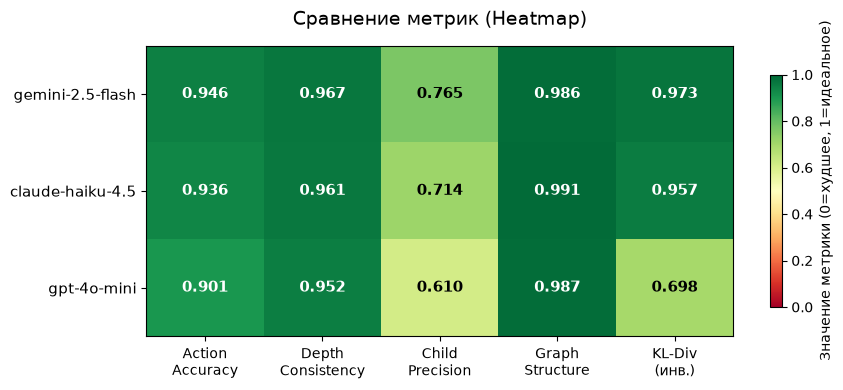

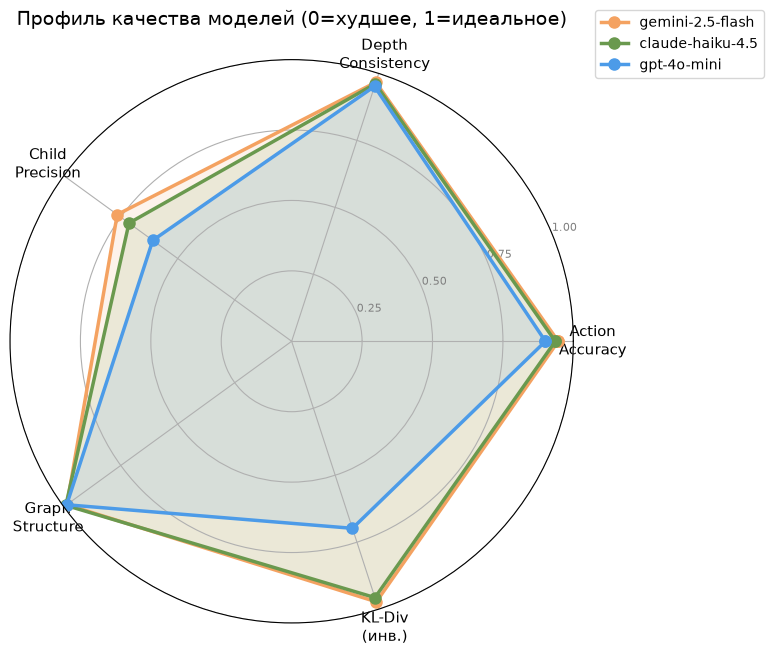

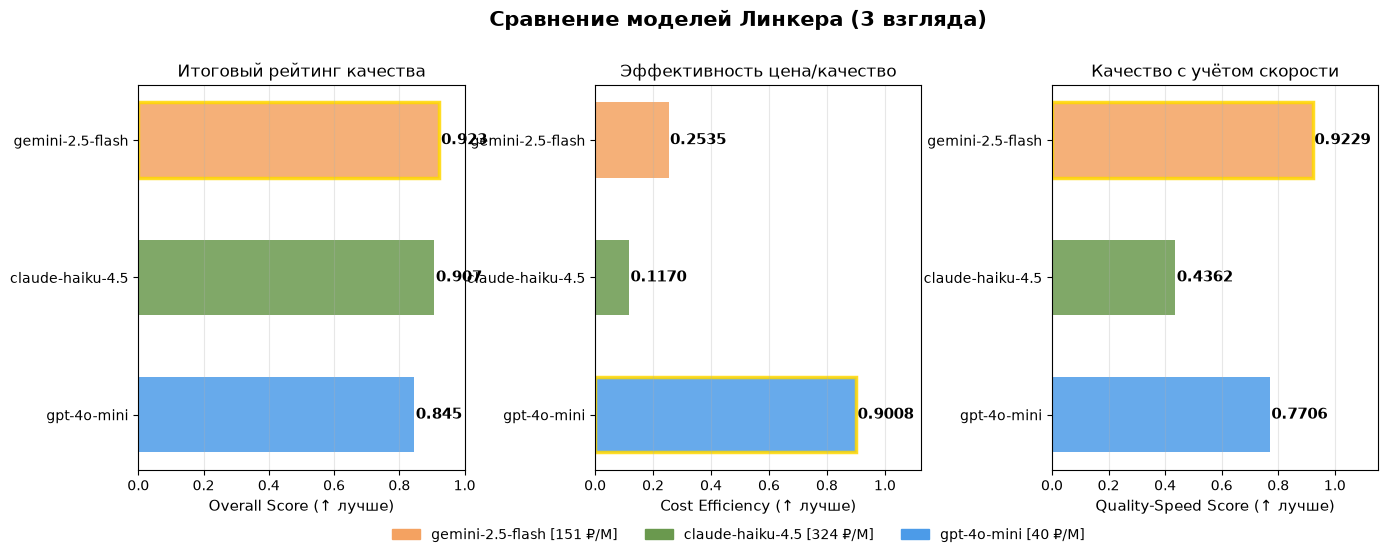

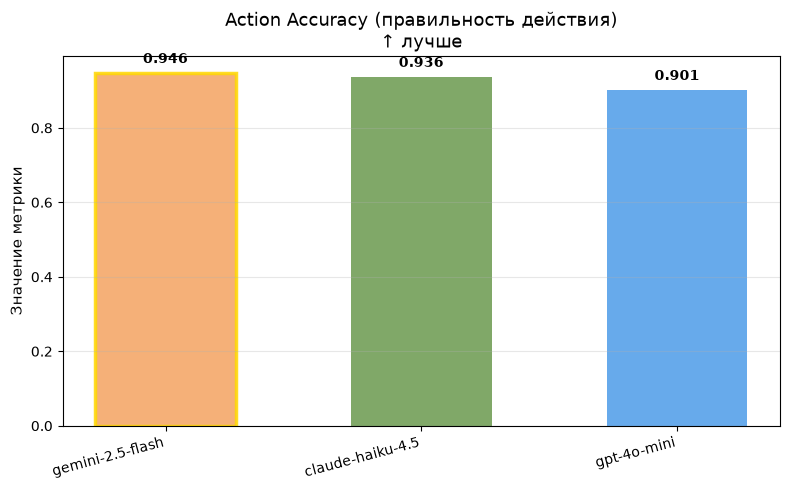

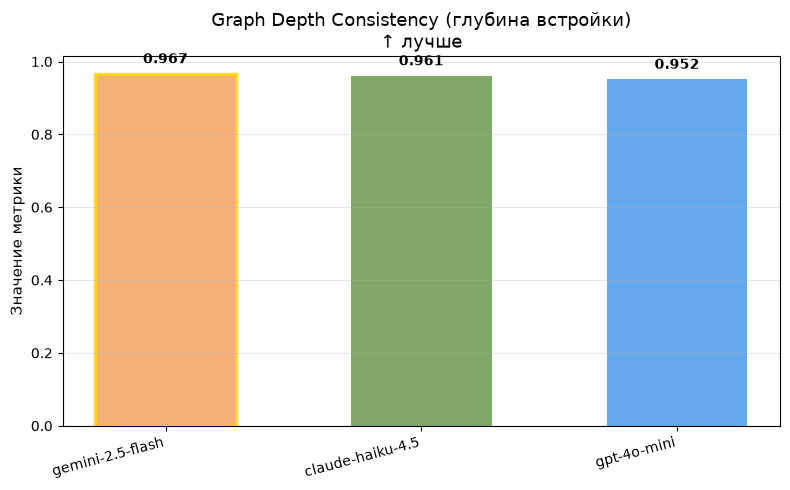

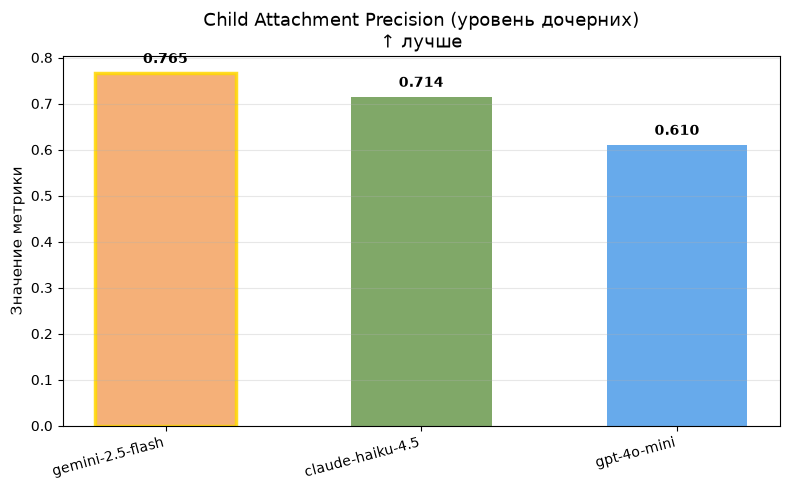

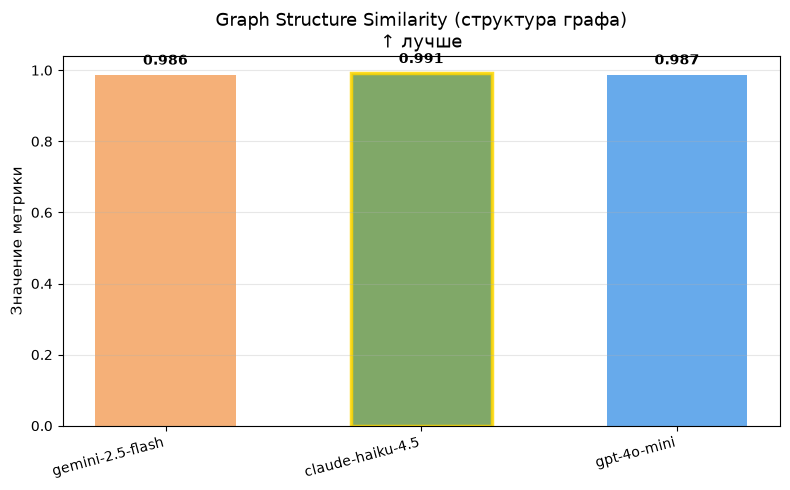

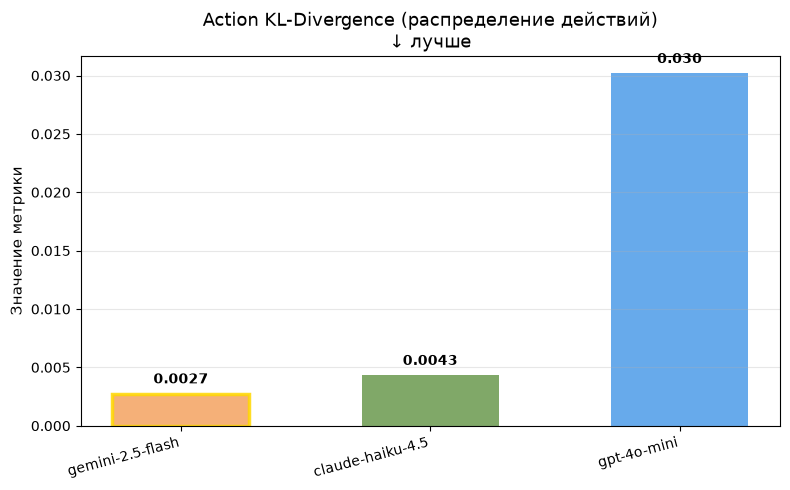

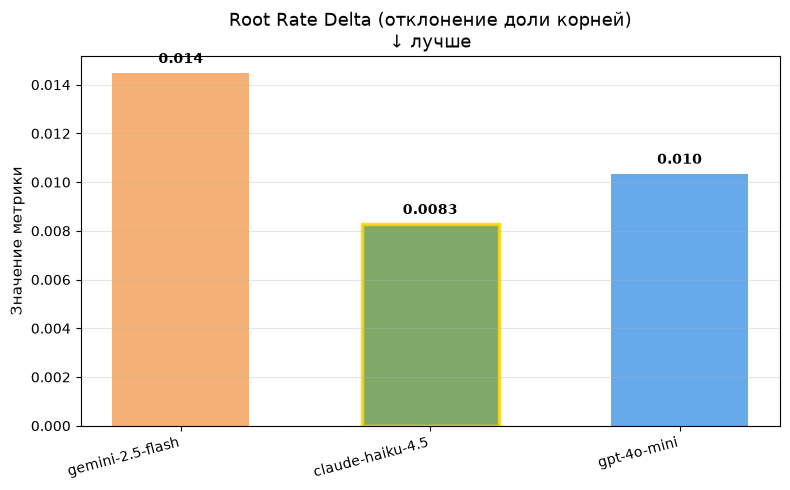

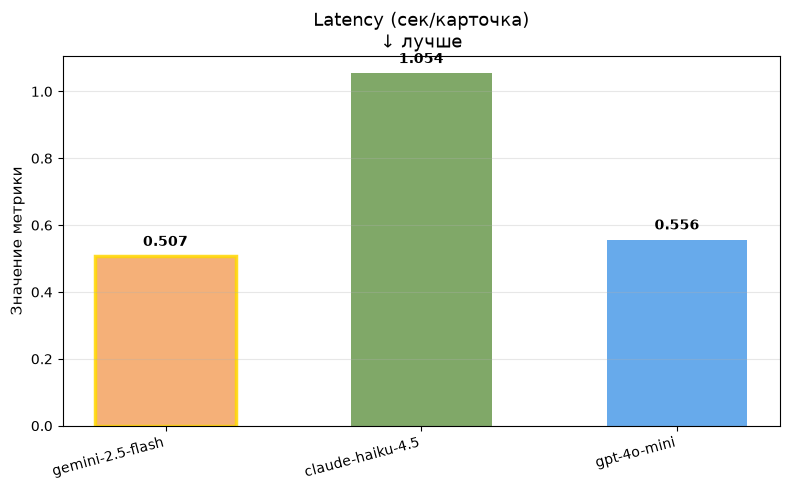

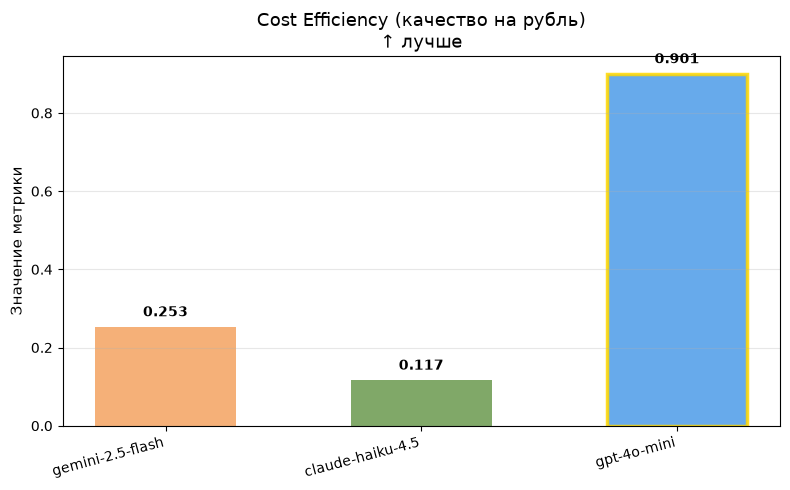

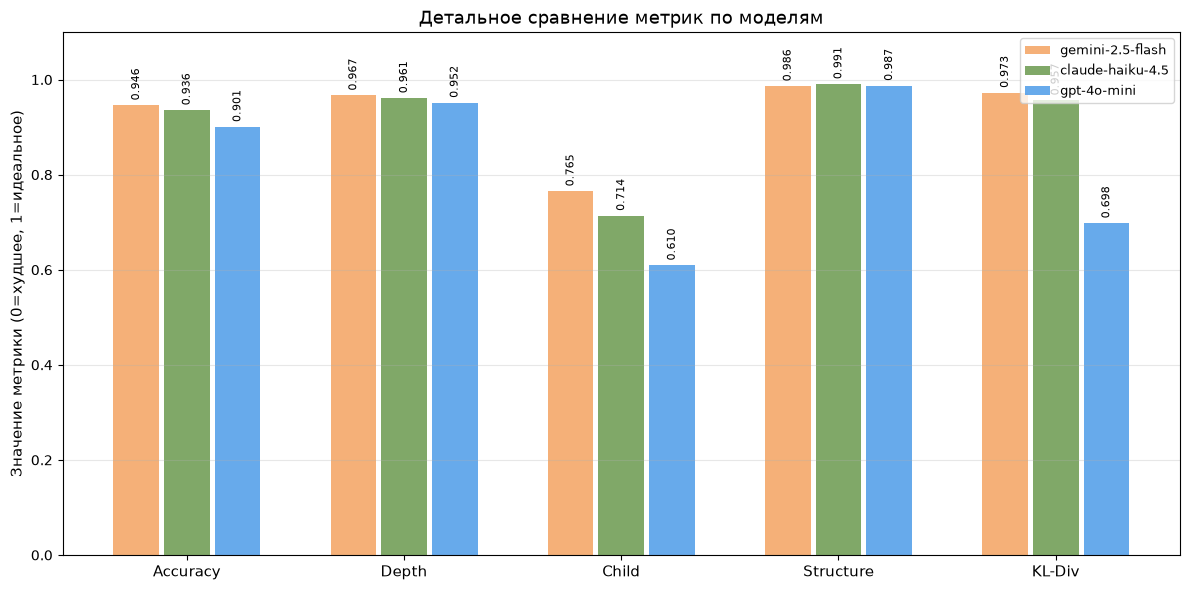

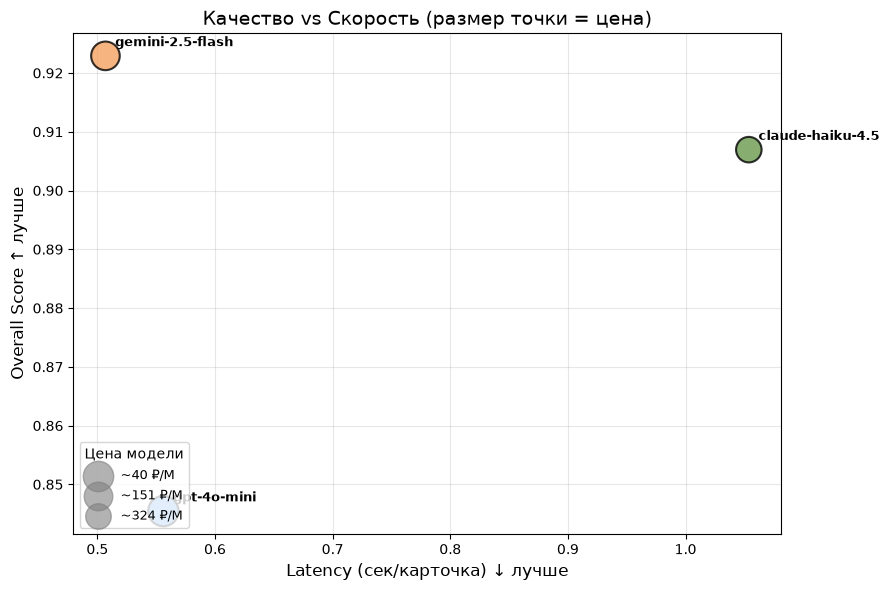

   ✅ Все графики сохранены в: /Users/nastya/github/Executive_Exocortex/eval/metric_results/linker
   ✅ Финальный рейтинг сохранён: metric_results/linker_final_ranking.xlsx
       ОТЧЁТ СРАВНЕНИЯ МОДЕЛЕЙ ЛИНКЕРА
       Создан: 2026-06-28 14:07

📊 Всего моделей: 3
📝 Карточек в тесте: 484
📁 Файл метрик: linker_metrics_summary.xlsx

─── РАЗВЁРНУТАЯ ТАБЛИЦА МЕТРИК ───

               model_name |             overall_score |       quality_speed_score |        quality_cost_score |           action_accuracy |   graph_depth_consistency | child_attachment_precision | graph_structure_similarity |      action_kl_divergence |           root_rate_delta |      latency_per_card_sec |           cost_efficiency |           cost_mean_per_M
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:


# ── ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ─────────────────────────────────────────────────

def get_color(model_name: str) -> str:
    for key, color in MODEL_COLORS.items():
        if key in str(model_name).lower():
            return color
    return DEFAULT_COLOR


def prepare_metrics_for_scoring(df: pd.DataFrame) -> pd.DataFrame:
    """
    Подготовка метрик для подсчета Overall Score.
    Для метрик в LOWER_IS_BETTER инвертируем значения.
    Метрики уже в диапазоне [0, 1], нормализация НЕ нужна.
    """
    df_prepared = df.copy()
    
    print("\n" + "=" * 100)
    print("🔧 ПОДГОТОВКА МЕТРИК ДЛЯ ПОДСЧЕТА OVERALL SCORE")
    print("=" * 100)
    
    for metric in METRIC_WEIGHTS.keys():
        if metric not in df.columns:
            print(f"\n❌ Метрика '{metric}' отсутствует в данных")
            continue
        
        col = df[metric].astype(float)
        
        print(f"\n📊 {metric}")
        print(f"   Исходные значения: {[f'{v:.6f}' for v in col.tolist()]}")
        
        if metric in LOWER_IS_BETTER:
            # Для метрик "чем меньше, тем лучше" инвертируем
            # Например, KL-divergence: 0.002 → score = 1 - 0.002 = 0.998
            # Но это работает только если метрика уже в [0, 1]
            
            # Для KL-divergence и подобных метрик делаем ограничение
            max_penalty = 0.1  # максимальный штраф
            inverted = 1.0 - col.clip(upper=max_penalty) / max_penalty
            
            df_prepared[metric] = inverted
            print(f"   ↓ LOWER_IS_BETTER → инвертировано (max_penalty={max_penalty})")
            print(f"   Финальные значения: {[f'{v:.6f}' for v in inverted.tolist()]}")
        else:
            # Для метрик "чем больше, тем лучше" оставляем как есть
            df_prepared[metric] = col
            print(f"   ↑ HIGHER_IS_BETTER → без изменений")
            print(f"   Финальные значения: {[f'{v:.6f}' for v in col.tolist()]}")
    
    print("\n" + "=" * 100)
    return df_prepared


def compute_overall_score(df_prepared: pd.DataFrame) -> pd.Series:
    """
    Взвешенная сумма метрик.
    Все метрики уже в формате "чем больше, тем лучше" и в диапазоне [0, 1].
    """
    score = pd.Series(0.0, index=df_prepared.index)
    
    print("\n" + "=" * 100)
    print("🎯 РАСЧЕТ OVERALL SCORE")
    print("=" * 100)
    
    for metric, weight in METRIC_WEIGHTS.items():
        if metric in df_prepared.columns:
            contribution = df_prepared[metric] * weight
            score += contribution
            print(f"\n{metric}:")
            print(f"  Вес: {weight:.2f}")
            print(f"  Вклад в общий скор: {contribution.tolist()}")
    
    print(f"\n✅ Итоговый Overall Score: {score.tolist()}")
    print("=" * 100)
    
    return score


def print_report_line(f, text, console=True):
    """Пишет строку в файл и опционально в консоль."""
    if console:
        print(text)
    f.write(text + "\n")


def print_metrics_summary(df: pd.DataFrame, df_prepared: pd.DataFrame) -> None:
    """Печатает исходные метрики и подготовленные метрики для скоринга."""
    print("\n" + "=" * 100)
    print("📊 ИСХОДНЫЕ МЕТРИКИ ПО МОДЕЛЯМ")
    print("=" * 100)
    
    metrics_to_show = list(METRIC_WEIGHTS.keys())
    additional_metrics = ["latency_per_card_sec", "cost_mean_per_M", "cost_efficiency"]
    all_metrics = metrics_to_show + additional_metrics
    available_metrics = [m for m in all_metrics if m in df.columns]
    
    df_display = df[["model_name"] + available_metrics].copy()
    print(df_display.to_string(index=False))
    
    print("\n" + "=" * 100)
    print("🔄 МЕТРИКИ ПОСЛЕ ПОДГОТОВКИ (для Overall Score)")
    print("   Примечание: метрики LOWER_IS_BETTER инвертированы")
    print("=" * 100)
    
    available_prepared = [m for m in metrics_to_show if m in df_prepared.columns]
    df_prepared_display = df_prepared[["model_name"] + available_prepared].copy()
    print(df_prepared_display.to_string(index=False))
    
    print("\n" + "=" * 100)


# ── ГРАФИКИ ПО КАЖДОЙ МЕТРИКЕ ───────────────────────────────────────────────

def plot_single_metric_bars(df: pd.DataFrame, metric: str, title: str, 
                           lower_better: bool = False) -> None:
    """Строит bar chart для одной метрики."""
    fig, ax = plt.subplots(figsize=(8, 5))
    
    models = df["model_name"].tolist()
    values = df[metric].tolist()
    colors = [get_color(m) for m in models]
    
    bars = ax.bar(models, values, color=colors, alpha=0.85, width=0.55)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                f"{val:.4f}" if val < 0.01 else f"{val:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    ax.set_ylabel("Значение метрики", fontsize=11)
    ax.set_title(f"{title}\n{'↓ лучше' if lower_better else '↑ лучше'}", fontsize=13)
    ax.grid(axis="y", alpha=0.3)
    
    best_val = min(values) if lower_better else max(values)
    best_idx = values.index(best_val)
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(2.5)
    
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    
    safe_name = metric.replace(" ", "_").replace("/", "_")
    plt.savefig(FIGURES_DIR / f"metric_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_all_single_metrics(df: pd.DataFrame) -> None:
    """Генерирует отдельные графики для каждой метрики."""
    metric_configs = [
        ("action_accuracy", "Action Accuracy (правильность действия)", False),
        ("graph_depth_consistency", "Graph Depth Consistency (глубина встройки)", False),
        ("child_attachment_precision", "Child Attachment Precision (уровень дочерних)", False),
        ("graph_structure_similarity", "Graph Structure Similarity (структура графа)", False),
        ("action_kl_divergence", "Action KL-Divergence (распределение действий)", True),
        ("root_rate_delta", "Root Rate Delta (отклонение доли корней)", True),
        ("latency_per_card_sec", "Latency (сек/карточка)", True),
        ("cost_efficiency", "Cost Efficiency (качество на рубль)", False),
    ]
    
    for metric, title, lower_better in metric_configs:
        if metric in df.columns:
            plot_single_metric_bars(df, metric, title, lower_better)


# ── ОСНОВНЫЕ ГРАФИКИ ─────────────────────────────────────────────────────────

def plot_metrics_radar(df_prepared: pd.DataFrame) -> None:
    """Radar chart — профиль каждой модели."""
    metrics = list(METRIC_WEIGHTS.keys())
    labels = [
        "Action\nAccuracy", "Depth\nConsistency", 
        "Child\nPrecision", "Graph\nStructure", "KL-Div\n(инв.)"
    ]
    
    n = len(metrics)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for _, row in df_prepared.iterrows():
        model = row["model_name"]
        values = [row[m] for m in metrics]
        values += values[:1]
        
        color = get_color(model)
        ax.plot(angles, values, "o-", linewidth=2.5, color=color, label=model, markersize=8)
        ax.fill(angles, values, alpha=0.12, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8, color="grey")
    ax.set_title("Профиль качества моделей (0=худшее, 1=идеальное)", fontsize=14, pad=25)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "radar_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_metrics_heatmap(df_prepared: pd.DataFrame) -> None:
    """Тепловая карта всех метрик."""
    metrics = list(METRIC_WEIGHTS.keys())
    metric_labels = [
        "Action\nAccuracy", "Depth\nConsistency", "Child\nPrecision", 
        "Graph\nStructure", "KL-Div\n(инв.)"
    ]
    
    data = df_prepared[metrics].values
    model_names = df_prepared["model_name"].tolist()
    
    fig, ax = plt.subplots(figsize=(9, max(4, len(model_names) * 1.2)))
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metric_labels, rotation=0, fontsize=10)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names, fontsize=11)
    
    for i in range(len(model_names)):
        for j in range(len(metrics)):
            val = data[i, j]
            text_color = "black" if 0.3 < val < 0.8 else "white"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=11, color=text_color, fontweight="bold")
    
    plt.colorbar(im, ax=ax, label="Значение метрики (0=худшее, 1=идеальное)", shrink=0.8)
    ax.set_title("Сравнение метрик (Heatmap)", fontsize=14, pad=15)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "metrics_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_overall_score_with_cost(df: pd.DataFrame) -> None:
    """Три графика: Overall Score, Cost Efficiency, Quality+Speed."""
    fig = plt.figure(figsize=(16, 5))
    gs = GridSpec(1, 3, figure=fig, wspace=0.4)
    
    models = df["model_name"].tolist()
    colors = [get_color(m) for m in models]
    
    # 1. Overall Score
    ax1 = fig.add_subplot(gs[0, 0])
    bars1 = ax1.barh(models, df["overall_score"], color=colors, alpha=0.85, height=0.55)
    for bar, score in zip(bars1, df["overall_score"]):
        ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{score:.3f}", va="center", fontsize=11, fontweight="bold")
    ax1.set_xlim(0, 1.0)
    ax1.set_xlabel("Overall Score (↑ лучше)", fontsize=11)
    ax1.set_title("Итоговый рейтинг качества", fontsize=12)
    ax1.invert_yaxis()
    ax1.grid(axis="x", alpha=0.3)
    best_idx = df["overall_score"].idxmax()
    bars1[list(df.index).index(best_idx)].set_edgecolor("gold")
    bars1[list(df.index).index(best_idx)].set_linewidth(2.5)
    
    # 2. Cost Efficiency
    ax2 = fig.add_subplot(gs[0, 1])
    bars2 = ax2.barh(models, df["cost_efficiency"], color=colors, alpha=0.85, height=0.55)
    for bar, ces in zip(bars2, df["cost_efficiency"]):
        ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{ces:.4f}", va="center", fontsize=11, fontweight="bold")
    ax2.set_xlim(0, max(df["cost_efficiency"].max() * 1.25, 0.01))
    ax2.set_xlabel("Cost Efficiency (↑ лучше)", fontsize=11)
    ax2.set_title("Эффективность цена/качество", fontsize=12)
    ax2.invert_yaxis()
    ax2.grid(axis="x", alpha=0.3)
    best_ces_idx = df["cost_efficiency"].idxmax()
    bars2[list(df.index).index(best_ces_idx)].set_edgecolor("gold")
    bars2[list(df.index).index(best_ces_idx)].set_linewidth(2.5)
    
    # 3. Quality-Speed Score
    if "latency_per_card_sec" in df.columns and df["latency_per_card_sec"].min() > 0:
        df_temp = df.copy()
        min_lat = df_temp["latency_per_card_sec"].min()
        df_temp["quality_speed"] = df_temp["overall_score"] / (df_temp["latency_per_card_sec"] / min_lat)
    else:
        df_temp = df.copy()
        df_temp["quality_speed"] = df_temp["overall_score"]
    
    ax3 = fig.add_subplot(gs[0, 2])
    bars3 = ax3.barh(models, df_temp["quality_speed"], color=colors, alpha=0.85, height=0.55)
    for bar, qs in zip(bars3, df_temp["quality_speed"]):
        ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{qs:.4f}", va="center", fontsize=11, fontweight="bold")
    ax3.set_xlim(0, max(df_temp["quality_speed"].max() * 1.25, 0.01))
    ax3.set_xlabel("Quality-Speed Score (↑ лучше)", fontsize=11)
    ax3.set_title("Качество с учётом скорости", fontsize=12)
    ax3.invert_yaxis()
    ax3.grid(axis="x", alpha=0.3)
    best_qs_idx = df_temp["quality_speed"].idxmax()
    bars3[list(df_temp.index).index(best_qs_idx)].set_edgecolor("gold")
    bars3[list(df_temp.index).index(best_qs_idx)].set_linewidth(2.5)
    
    # Легенда с ценами
    legend_patches = [
        mpatches.Patch(color=get_color(row["model_name"]),
                       label=f"{row['model_name']} [{row.get('cost_mean_per_M', 0):.0f} ₽/М]")
        for _, row in df.iterrows()
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=len(df),
               fontsize=10, bbox_to_anchor=(0.5, -0.06), frameon=False)
    
    plt.suptitle("Сравнение моделей Линкера (3 взгляда)", fontsize=15, fontweight="bold", y=1.03)
    plt.savefig(FIGURES_DIR / "overall_comparison_3panels.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_latency_with_quality(df: pd.DataFrame) -> None:
    """Scatter plot: latency vs overall score с размером точки = цена."""
    fig, ax = plt.subplots(figsize=(9, 6))
    
    models = df["model_name"].tolist()
    latencies = df["latency_per_card_sec"].tolist()
    scores = df["overall_score"].tolist()
    costs = df["cost_mean_per_M"].tolist() if "cost_mean_per_M" in df.columns else [100]*len(models)
    colors = [get_color(m) for m in models]
    
    # Нормируем размер точки
    sizes = [max(100, 500 - c/2) for c in costs]
    
    scatter = ax.scatter(latencies, scores, s=sizes, c=colors, alpha=0.8, 
                        edgecolors="black", linewidth=1.5, zorder=5)
    
    # Подписи моделей
    for i, model in enumerate(models):
        ax.annotate(model, (latencies[i], scores[i]), 
                   xytext=(7, 7), textcoords="offset points", 
                   fontsize=9, fontweight="bold")
    
    ax.set_xlabel("Latency (сек/карточка) ↓ лучше", fontsize=12)
    ax.set_ylabel("Overall Score ↑ лучше", fontsize=12)
    ax.set_title("Качество vs Скорость (размер точки = цена)", fontsize=14)
    ax.grid(alpha=0.3)
    
    # Легенда для цен
    legend_elements = []
    for cost in sorted(set(costs)):
        legend_elements.append(
            plt.scatter([], [], s=max(100, 500 - cost/2), 
                       color="grey", alpha=0.6, 
                       label=f"~{cost:.0f} ₽/М")
        )
    ax.legend(handles=legend_elements, title="Цена модели", 
             loc="lower left", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "latency_vs_quality.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_prepared_metrics_grouped(df_prepared: pd.DataFrame) -> None:
    """Grouped bar chart всех подготовленных метрик для всех моделей."""
    metrics = list(METRIC_WEIGHTS.keys())
    metric_labels = ["Accuracy", "Depth", "Child", "Structure", "KL-Div"]
    n_models = len(df_prepared)
    n_metrics = len(metrics)
    
    x = np.arange(n_metrics)
    width = 0.7 / n_models
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = [get_color(m) for m in df_prepared["model_name"]]
    
    for i, (_, row) in enumerate(df_prepared.iterrows()):
        values = [row[m] for m in metrics]
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, values, width * 0.9, 
                     label=row["model_name"], color=colors[i], alpha=0.85)
        
        # Подписи значений
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f"{val:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_ylabel("Значение метрики (0=худшее, 1=идеальное)", fontsize=11)
    ax.set_title("Детальное сравнение метрик по моделям", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "grouped_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ── ГЛАВНАЯ ФУНКЦИЯ ──────────────────────────────────────────────────────────

def run_comparison():
    print("=" * 70)
    print("       ПОЛНЫЙ АНАЛИЗ И СРАВНЕНИЕ МОДЕЛЕЙ ЛИНКЕРА")
    print("=" * 70)
    
    if not METRICS_FILE.exists():
        print(f"❌ Файл {METRICS_FILE} не найден. Сначала запустите расчет метрик.")
        return
    
    # 1. Загрузка
    df = pd.read_excel(METRICS_FILE)
    print(f"\n📥 Загружено {len(df)} моделей из {METRICS_FILE.name}")
    print(f"   Модели: {', '.join(df['model_name'].tolist())}")
    
    # 2. Подготовка метрик (инвертирование LOWER_IS_BETTER, БЕЗ нормализации)
    df_prepared = prepare_metrics_for_scoring(df)
    
    # 3. Печать исходных и подготовленных метрик
    print_metrics_summary(df, df_prepared)
    
    # 4. Overall Score
    df["overall_score"] = compute_overall_score(df_prepared)
    
    # 5. Дополнительные скоры
    if "latency_per_card_sec" in df.columns and df["latency_per_card_sec"].min() > 0:
        min_lat = df["latency_per_card_sec"].min()
        df["quality_speed_score"] = df["overall_score"] / (df["latency_per_card_sec"] / min_lat)
    else:
        df["quality_speed_score"] = df["overall_score"]
    
    if "cost_mean_per_M" in df.columns and df["cost_mean_per_M"].min() > 0:
        min_cost = df["cost_mean_per_M"].min()
        df["quality_cost_score"] = df["overall_score"] / (df["cost_mean_per_M"] / min_cost)
    else:
        df["quality_cost_score"] = df["overall_score"]
    
    # 6. Сортировка
    df = df.sort_values("overall_score", ascending=False).reset_index(drop=True)
    # Сортируем df_prepared в том же порядке
    df_prepared["model_name"] = df["model_name"]
    df_prepared = df_prepared.set_index("model_name").loc[df["model_name"]].reset_index()
    
    # 7. Генерация графиков
    print("\n📈 Генерация 8+ графиков...")
    
    # Основные
    plot_metrics_heatmap(df_prepared)
    plot_metrics_radar(df_prepared)
    plot_overall_score_with_cost(df)
    
    # Дополнительные по каждой метрике
    plot_all_single_metrics(df)
    
    # Специальные
    plot_prepared_metrics_grouped(df_prepared)
    plot_latency_with_quality(df)
    
    print(f"   ✅ Все графики сохранены в: {FIGURES_DIR.absolute()}")
    
    # 8. Сохранение финальной таблицы
    final_path = FIGURES_DIR.parent / "linker_final_ranking.xlsx"
    cols_order = ["model_name", "overall_score", "quality_speed_score", "quality_cost_score"] + \
                 [c for c in df.columns if c not in ["model_name", "overall_score", 
                                                     "quality_speed_score", "quality_cost_score"]]
    df[cols_order].to_excel(final_path, index=False)
    print(f"   ✅ Финальный рейтинг сохранён: {final_path}")
    
    # 9. Текстовый отчёт
    with open(REPORT_FILE, "w", encoding="utf-8") as f:
        print_report_line(f, "=" * 70)
        print_report_line(f, "       ОТЧЁТ СРАВНЕНИЯ МОДЕЛЕЙ ЛИНКЕРА")
        print_report_line(f, f"       Создан: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
        print_report_line(f, "=" * 70)
        print_report_line(f, "")
        
        # Общая информация
        print_report_line(f, f"📊 Всего моделей: {len(df)}")
        print_report_line(f, f"📝 Карточек в тесте: {df['n_cards'].iloc[0] if 'n_cards' in df.columns else 'N/A'}")
        print_report_line(f, f"📁 Файл метрик: {METRICS_FILE.name}")
        print_report_line(f, "")
        
        # Таблица метрик
        print_report_line(f, "─── РАЗВЁРНУТАЯ ТАБЛИЦА МЕТРИК ───")
        print_report_line(f, "")
        
        metrics_columns = ["model_name", "overall_score", "quality_speed_score", "quality_cost_score",
                          "action_accuracy", "graph_depth_consistency", "child_attachment_precision",
                          "graph_structure_similarity", "action_kl_divergence", "root_rate_delta",
                          "latency_per_card_sec", "cost_efficiency", "cost_mean_per_M"]
        
        available_cols = [c for c in metrics_columns if c in df.columns]
        
        # Печатаем заголовки
        header = " | ".join([f"{c:>25}" for c in available_cols])
        print_report_line(f, header)
        print_report_line(f, "-" * len(header))
        
        for _, row in df.iterrows():
            row_str = " | ".join([
                f"{str(row[c])[:25]:>25}" if isinstance(row[c], str) 
                else f"{row[c]:>25.4f}" if isinstance(row[c], float)
                else f"{str(row[c]):>25}"
                for c in available_cols
            ])
            print_report_line(f, row_str)
        
        print_report_line(f, "")
        print_report_line(f, "")
        
        # Рейтинг по качеству
        print_report_line(f, "─── РЕЙТИНГ ПО КАЧЕСТВУ (Overall Score) ───")
        print_report_line(f, "")
        
        ranked_by_quality = df.sort_values("overall_score", ascending=False)
        for i, (_, row) in enumerate(ranked_by_quality.iterrows(), 1):
            medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(i, f"  {i}.")
            print_report_line(f, f"  {medal} {row['model_name']:35s} Score: {row['overall_score']:.4f}")
        
        print_report_line(f, "")
        
        # Рейтинг по цена/качество
        print_report_line(f, "─── РЕЙТИНГ ПО ЦЕНА/КАЧЕСТВО (Cost Efficiency) ───")
        print_report_line(f, "")
        
        ranked_by_cost = df.sort_values("cost_efficiency", ascending=False)
        for i, (_, row) in enumerate(ranked_by_cost.iterrows(), 1):
            medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(i, f"  {i}.")
            print_report_line(f, f"  {medal} {row['model_name']:35s} CES: {row['cost_efficiency']:.4f}  "
                             f"(цена: {row.get('cost_mean_per_M', 0):.0f} ₽/М)")
        
        print_report_line(f, "")
        
        # Рейтинг по качество+скорость
        print_report_line(f, "─── РЕЙТИНГ ПО КАЧЕСТВО+СКОРОСТЬ (Quality-Speed Score) ───")
        print_report_line(f, "")
        
        ranked_by_speed = df.sort_values("quality_speed_score", ascending=False)
        for i, (_, row) in enumerate(ranked_by_speed.iterrows(), 1):
            medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(i, f"  {i}.")
            print_report_line(f, f"  {medal} {row['model_name']:35s} QSS: {row['quality_speed_score']:.4f}  "
                             f"(latency: {row['latency_per_card_sec']:.2f} сек)")
        
        print_report_line(f, "")
        print_report_line(f, "")
        
        # Победители
        best_quality = df.iloc[0]
        best_cost = df.loc[df["cost_efficiency"].idxmax()]
        best_speed = df.loc[df["quality_speed_score"].idxmax()]
        
        print_report_line(f, "🏆  ИТОГОВЫЕ РЕКОМЕНДАЦИИ")
        print_report_line(f, "")
        
        print_report_line(f, f"  🥇 Лучшее качество (без учёта цены):")
        print_report_line(f, f"       {best_quality['model_name']}")
        print_report_line(f, f"       Overall Score: {best_quality['overall_score']:.4f}")
        print_report_line(f, f"       Action Accuracy: {best_quality['action_accuracy']:.3f}")
        print_report_line(f, f"       Latency: {best_quality['latency_per_card_sec']:.2f} сек/карт.")
        print_report_line(f, f"       Цена: {best_quality.get('cost_mean_per_M', 'N/A'):.0f} ₽/М")
        print_report_line(f, "")
        
        print_report_line(f, f"  💰 Лучшее соотношение цена/качество:")
        print_report_line(f, f"       {best_cost['model_name']}")
        print_report_line(f, f"       Cost Efficiency: {best_cost['cost_efficiency']:.4f}")
        print_report_line(f, f"       Overall Score: {best_cost['overall_score']:.4f}")
        print_report_line(f, f"       Цена: {best_cost.get('cost_mean_per_M', 'N/A'):.0f} ₽/М")
        print_report_line(f, "")
        
        print_report_line(f, f"  ⚡ Лучшее качество с учётом скорости:")
        print_report_line(f, f"       {best_speed['model_name']}")
        print_report_line(f, f"       Quality-Speed Score: {best_speed['quality_speed_score']:.4f}")
        print_report_line(f, f"       Overall Score: {best_speed['overall_score']:.4f}")
        print_report_line(f, f"       Latency: {best_speed['latency_per_card_sec']:.2f} сек/карт.")
        print_report_line(f, "")
        
        print_report_line(f, "─" * 70)
        print_report_line(f, "Конец отчёта")
    
    print(f"\n📄 Текстовый отчёт сохранён: {REPORT_FILE}")
    
    # 10. Вывод в консоль
    print("\n" + "=" * 70)
    print("🏆  ИТОГОВЫЙ РЕЙТИНГ")
    print("=" * 70)
    
    best_quality = df.iloc[0]
    best_cost = df.loc[df["cost_efficiency"].idxmax()]
    best_speed = df.loc[df["quality_speed_score"].idxmax()]
    
    print(f"\n🥇 ЛУЧШЕЕ КАЧЕСТВО:     {best_quality['model_name']}")
    print(f"    Overall Score:         {best_quality['overall_score']:.4f}")
    print(f"    Action Accuracy:       {best_quality['action_accuracy']:.3f}")
    print(f"    Скорость:              {best_quality['latency_per_card_sec']:.2f} сек/карт.")
    print(f"    Средняя цена:          {best_quality['cost_mean_per_M']:.1f} ₽/М")
    
    print(f"\n💰 ЛУЧШЕЕ ЦЕНА/КАЧЕСТВО:  {best_cost['model_name']}")
    print(f"    Cost Efficiency:       {best_cost['cost_efficiency']:.4f}")
    print(f"    Overall Score:         {best_cost['overall_score']:.4f}")
    print(f"    Средняя цена:          {best_cost['cost_mean_per_M']:.1f} ₽/М")
    
    print(f"\n⚡ ЛУЧШЕЕ КАЧ+СКОРОСТЬ:   {best_speed['model_name']}")
    print(f"    Quality-Speed Score:   {best_speed['quality_speed_score']:.4f}")
    print(f"    Overall Score:         {best_speed['overall_score']:.4f}")
    print(f"    Скорость:              {best_speed['latency_per_card_sec']:.2f} сек/карт.")
    
    print("\n" + "─" * 70)
    print("✅ Анализ завершён. Графики и отчёт сохранены.")
    
    return df


if __name__ == "__main__":
    result = run_comparison()